# Differential abundance analysis of scRNA data
- load frequency table
- run CLR transfomration
- run linear mixed models

# Setup

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('dplyr')
quiet_library('viridis')
quiet_library('lmerTest')
quiet_library('broom.mixed')
quiet_library('rstatix')
quiet_library('data.table')
quiet_library('ggpubr')

Warning message:
“package ‘dplyr’ was built under R version 4.3.3”


In [2]:
# define file path
# define working path
data_path = '/home/jupyter/data/ra_longitudinal/output_results/certPro'
fig_path = '/home/jupyter/data/ra_longitudinal/figures/DA'
meta_path = '/home/jupyter/github/ra-longitudinal/metadata'
output_path = '/home/jupyter/data/ra_longitudinal/output_results/certPro'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name = 'ALTRA_scRNA_AIFI_L3_deepclean_certpro_'

In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
ari_colors = c('#4C8CBD', '#F59F00', '#840032')
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 6, repr.plot.height = 6)

In [4]:
source('/home/jupyter/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r')

# Run DA analysis for cert pro deep clean data

In [5]:
# load the single cell metadata
certpro_meta = fread(file.path(data_path, 'ALTRA_scRNA_AIFI_L3_deepclean_certpro_meta_data.tsv'))

# AIM1

## Calculate the frequency based on the metadata

In [6]:
# load scrna file desc
aim1_scrna_meta = read_csv(file.path(meta_path, 'ALTRA_RA_Aim1_ALTRA_at_risk_vs_HCs_scrna_metadata.csv'),
                          show_col_types = FALSE)
aim1_scrna_meta%>%colnames()

[1] "lastUpdated"                         "sample.id"                          
 [3] "sample.bridgingControl"              "sample.sampleKitGuid"               
 [5] "sample.visitName"                    "sample.visitDetails"                
 [7] "sample.drawDate"                     "sample.daysSinceFirstVisit"         
 [9] "sample.diseaseStatesRecordedAtVisit" "file.id"                            
[11] "file.name"                           "file.batchID"                       
[13] "file.panel"                          "file.pool"                          
[15] "file.fileType"                       "file.userTags.details"              
[17] "file.userTags.group"                 "file.userTags.name"                 
[19] "file.userTags.origin"                "file.userTags.other"                
[21] "file.userTags.version"               "file.majorVersion"                  
[23] "subject.id"                          "subject.biologicalSex"              
[25] "subject.birthYear"                   "subject.ethnicity"                  
[27] "subject.partnerCode"                 "subject.race"                       
[29] "subject.subjectGuid"                 "cohort.cohortGuid"                  
[31] "status"                              "age"

In [7]:
# add age to the metadata
aim1_certpro_meta <- certpro_meta %>% inner_join(
    select(aim1_scrna_meta, c(sample.sampleKitGuid, age)), by='sample.sampleKitGuid')
aim1_certpro_meta%>%colnames()

[1] "V1"                                  "barcodes"                           
 [3] "batch_id"                            "cell_name"                          
 [5] "cell_uuid"                           "chip_id"                            
 [7] "hto_barcode"                         "hto_category"                       
 [9] "n_genes"                             "n_mito_umis"                        
[11] "n_reads"                             "n_umis"                             
[13] "original_barcodes"                   "pbmc_sample_id"                     
[15] "pool_id"                             "well_id"                            
[17] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
[19] "subject.subjectGuid"                 "subject.biologicalSex"              
[21] "subject.race"                        "subject.ethnicity"                  
[23] "subject.birthYear"                   "sample.visitName"                   
[25] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[27] "sample.daysSinceFirstVisit"          "file.id"                            
[29] "subset_grp"                          "predicted_doublet"                  
[31] "doublet_score"                       "AIFI_L1"                            
[33] "AIFI_L1_score"                       "AIFI_L2"                            
[35] "AIFI_L2_score"                       "AIFI_L3"                            
[37] "AIFI_L3_score"                       "n_genes_by_counts"                  
[39] "log1p_n_genes_by_counts"             "total_counts"                       
[41] "log1p_total_counts"                  "pct_counts_in_top_50_genes"         
[43] "pct_counts_in_top_100_genes"         "pct_counts_in_top_200_genes"        
[45] "pct_counts_in_top_500_genes"         "total_counts_mito"                  
[47] "log1p_total_counts_mito"             "pct_counts_mito"                    
[49] "leiden_harmony_2"                    "doublets_manual"                    
[51] "AIFI_L3_new"                         "Status_Xsec"                        
[53] "Status_Long"                         "anti_ccp3_finalCombined"            
[55] "days_to_conversion"                  "BMI"                                
[57] "CMV_Status_Subj"                     "age_conv"                           
[59] "bmi_conv"                            "file.batchID"                       
[61] "status"                              "age"

In [8]:
# calculate the frequency of AIM1
# for CLR transformation, to avoid log of 0, 
# we added a pseudo count 1 to all cell types and recalucalate the frequency
# then perform the CLR transformation 
aim1_aifi_l3_freq <- calculate_pseudo_frequencies(
    aim1_certpro_meta, celltype_column = 'AIFI_L3_new',
    sample_id_column = 'sample.sampleKitGuid', 
    metadata_columns = c('subject.subjectGuid', 'subject.biologicalSex', 
                         'BMI','CMV_Status_Subj', 'status', 
                         'age', 'file.batchID', 'Status_Xsec'))

In [9]:
aim1_aifi_l3_freq%>%head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency
<fct>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.65716,Negative,at_risk,56,B140,at_risk,0.0000000000,5.721478e-05
Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.94834,Negative,at_risk,42,B002,at_risk,0.0003928347,4.681283e-04
Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.12653,Positive,at_risk,21,B002,at_risk,0.0004216918,5.022602e-04
Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.67950,Positive,at_risk,78,B001,at_risk,0.0001740543,2.308802e-04
Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.80398,Negative,at_risk,40,B002,at_risk,0.0003462304,4.294795e-04
Activated memory B cell,KT00063,2,3,16604,CU1011,Male,28.12331,Negative,at_risk,39,B140,at_risk,0.0001211020,1.806794e-04


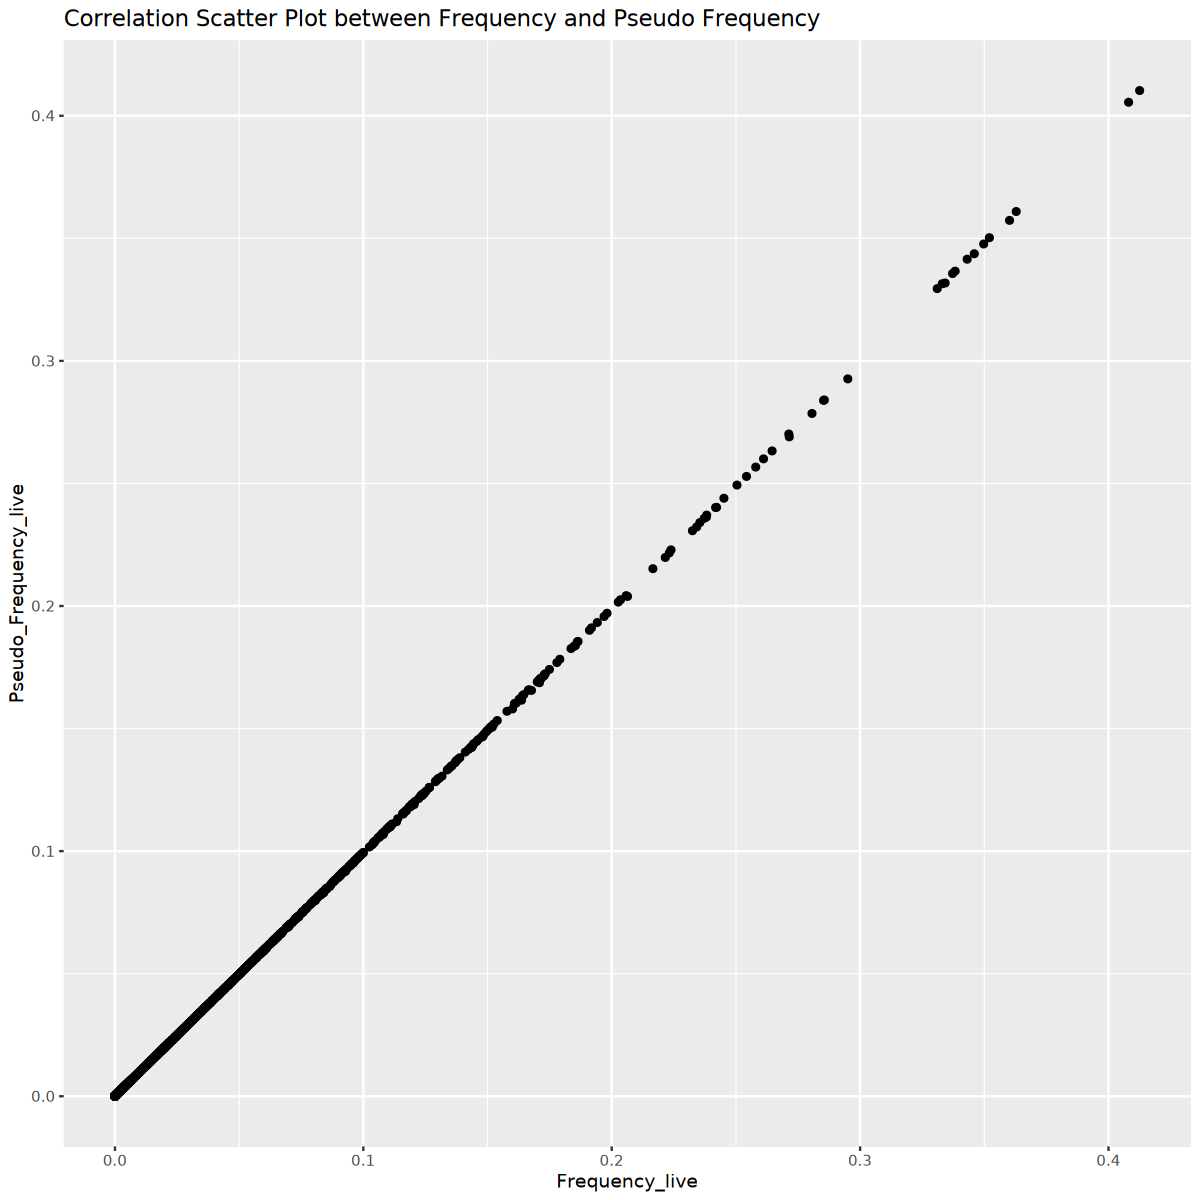

In [10]:
options(repr.plot.width = 10, repr.plot.height = 10)
# double check the Pseudo Frequency and the original frequency
ggplot(aim1_aifi_l3_freq, aes(x = frequency, y = pseudo_frequency)) +
  geom_point() +
  labs(x = "Frequency_live", y = "Pseudo_Frequency_live") +
  ggtitle("Correlation Scatter Plot between Frequency and Pseudo Frequency")


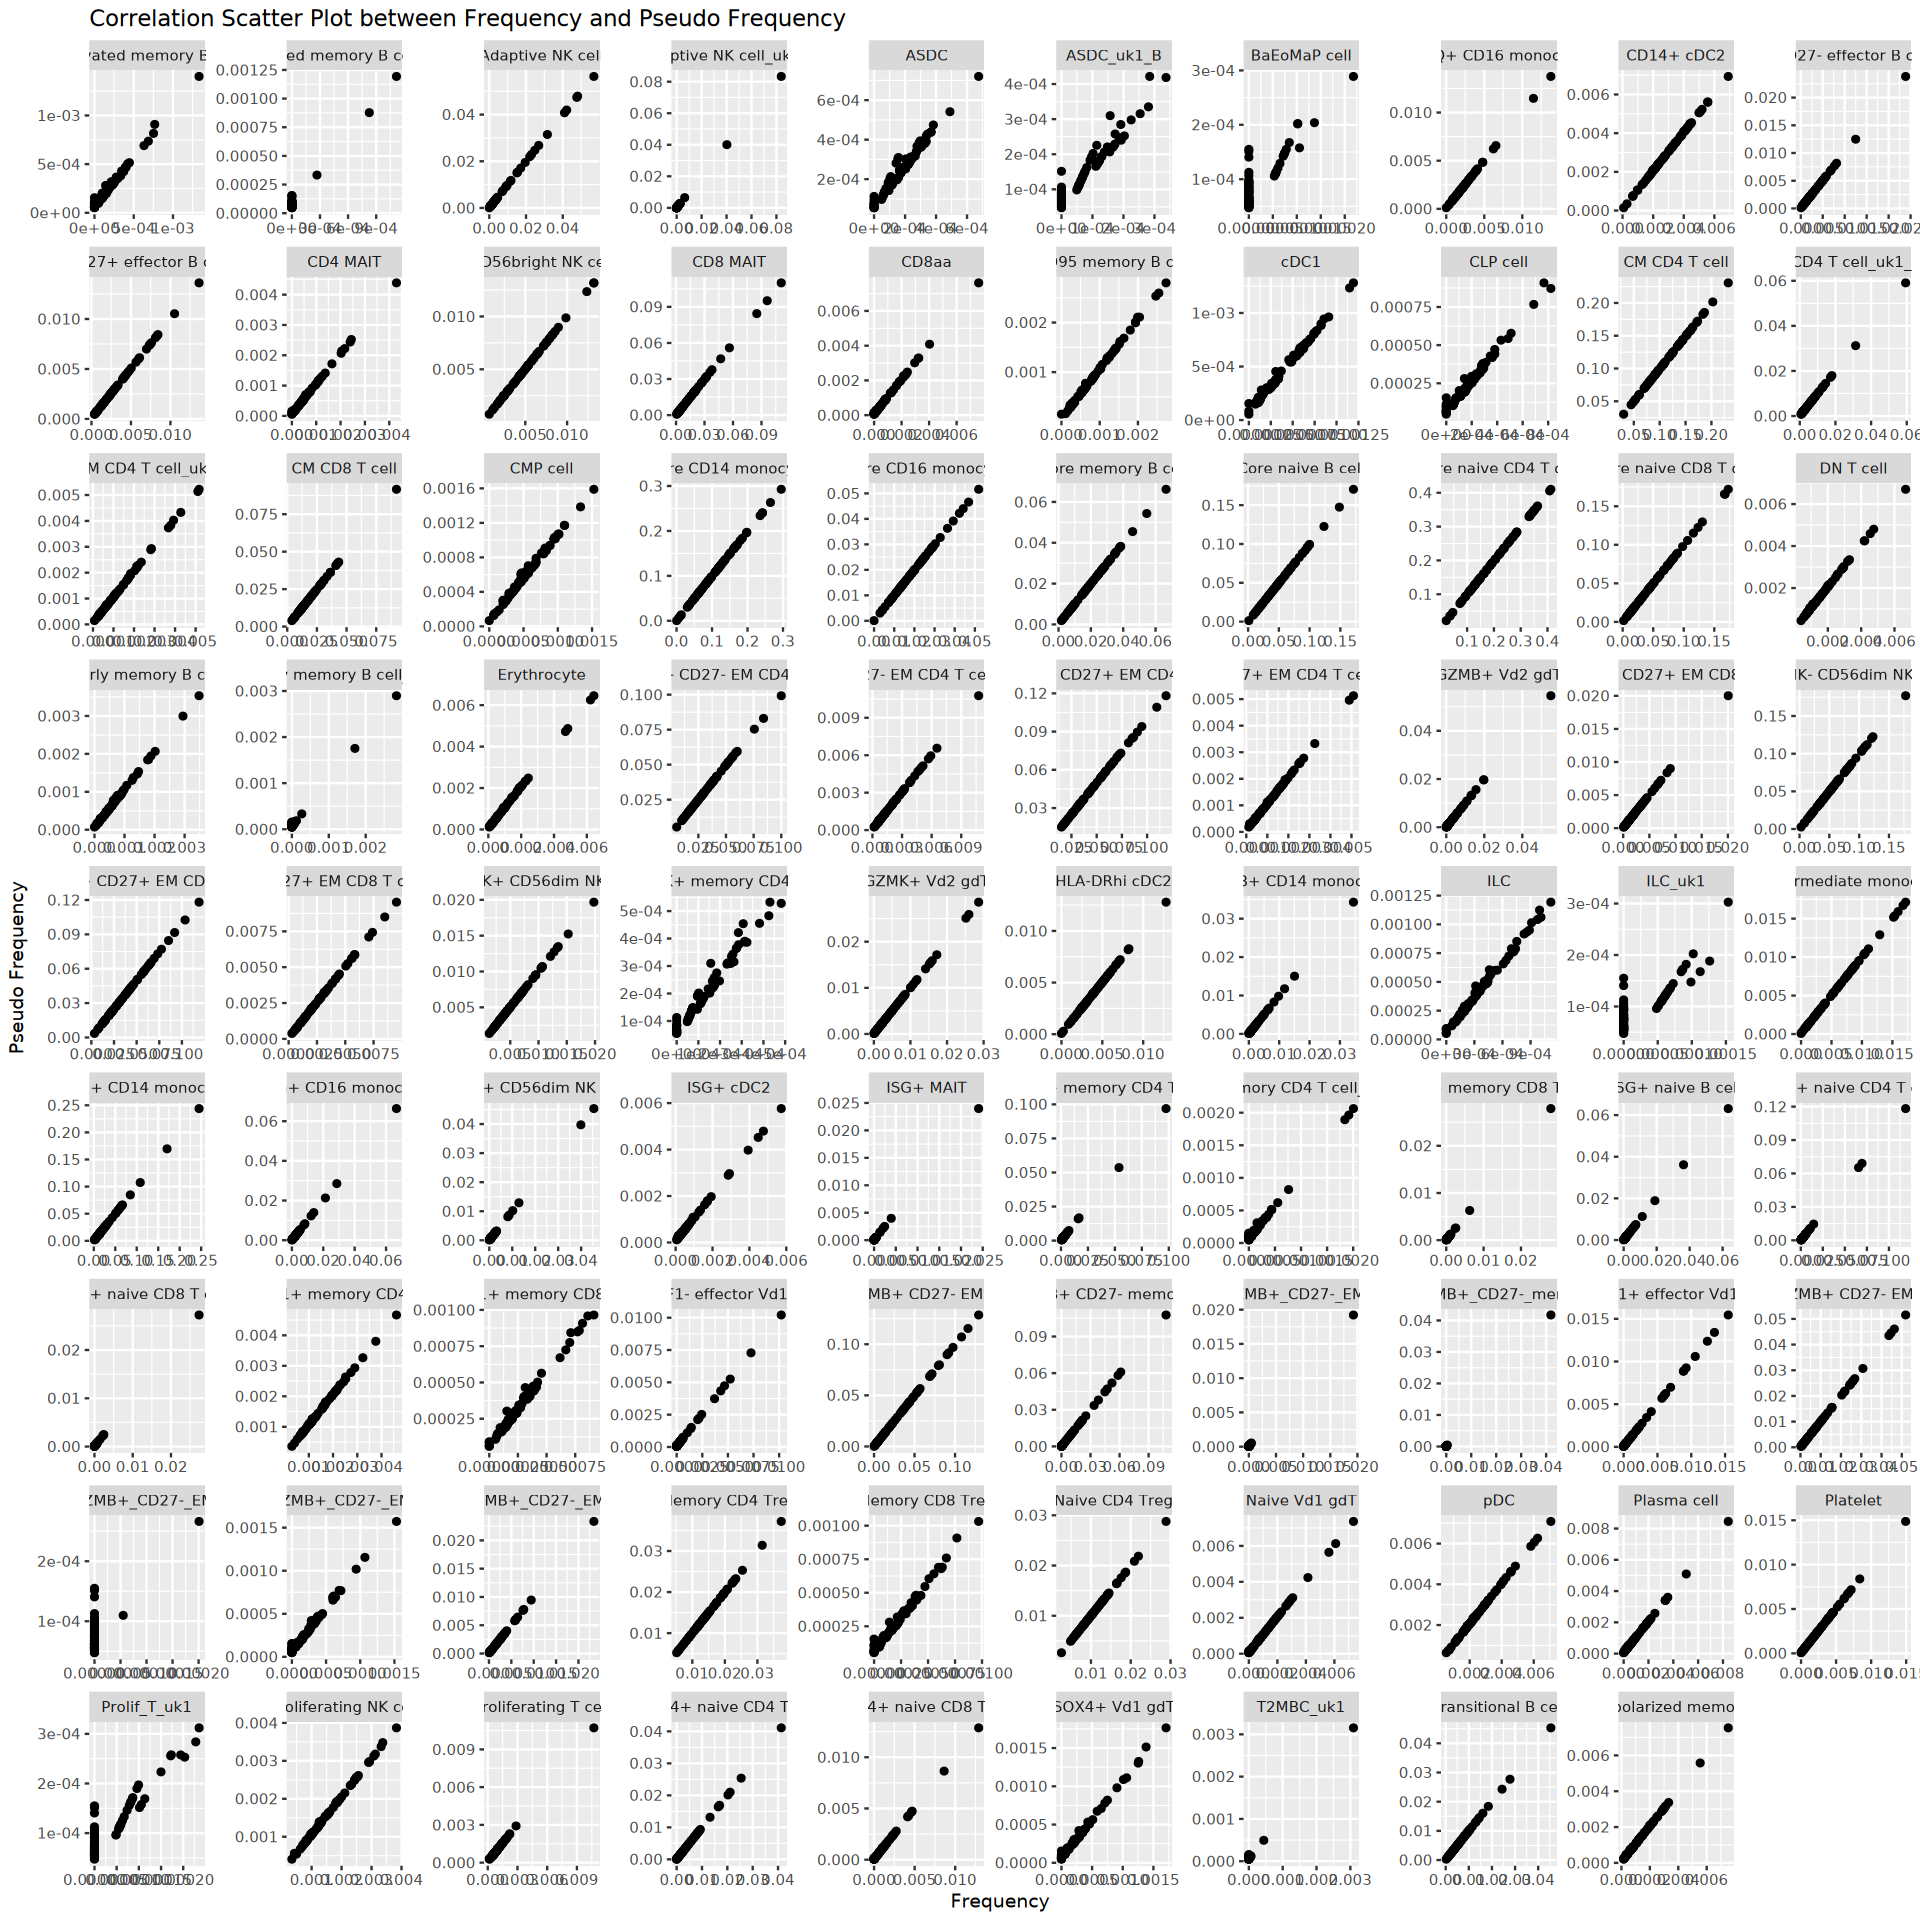

In [11]:
# Plotting correlation scatter plot for each l3 category
options(repr.plot.width = 16, repr.plot.height = 16)
p=ggplot(aim1_aifi_l3_freq, aes(x = frequency, y = pseudo_frequency)) +
  geom_point() +
  labs(x = "Frequency", y = "Pseudo Frequency") +
  ggtitle("Correlation Scatter Plot between Frequency and Pseudo Frequency") +
  facet_wrap(~ AIFI_L3_new, scales = "free")
p

In [12]:
# perform clr transformation
aim1_aifi_l3_freq <- FreqClrTran(aim1_aifi_l3_freq, freq_col='pseudo_frequency',
                                   celltype_col='AIFI_L3_new', clr_name='pseudo_clr',
                          sample_col='sample.sampleKitGuid')

Loading required package: compositions

Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:Matrix’:

    norm


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




In [13]:
# save aim1 frequency table
aim1_aifi_l3_freq%>%write_csv(file.path(output_path, paste0(proj_name, 'AIM1_frequency_table.csv')))

## run statistical test

In [18]:
aim1_aifi_l3_freq%>%head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.65716,Negative,at_risk,56,B140,at_risk,0.0000000000,5.721478e-05,-3.129493
Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.94834,Negative,at_risk,42,B002,at_risk,0.0003928347,4.681283e-04,-1.334438
Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.12653,Positive,at_risk,21,B002,at_risk,0.0004216918,5.022602e-04,-1.454036
Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.67950,Positive,at_risk,78,B001,at_risk,0.0001740543,2.308802e-04,-1.750482
Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.80398,Negative,at_risk,40,B002,at_risk,0.0003462304,4.294795e-04,-1.265923
Activated memory B cell,KT00063,2,3,16604,CU1011,Male,28.12331,Negative,at_risk,39,B140,at_risk,0.0001211020,1.806794e-04,-2.086592


In [19]:
aim1_aifi_l3_freq%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)%>%group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
at_risk,45


In [90]:
# filter cell type that are too rare to do analysis
rare_celltype <- aim1_aifi_l3_freq %>% dplyr::filter(counts==0)%>%
    group_by(AIFI_L3_new)%>%tally()%>% arrange(desc(n))%>%
    filter(n>76/2)%>%
    pull(AIFI_L3_new)
rare_celltype

[1] "KLRF1+_GZMB+_CD27-_EM_CD8_uk1"  "Activated memory B cell_uk1"   
[3] "T2MBC_uk1"                      "Early memory B cell_uk1"       
[5] "KLRF1-_GZMB+_CD27-_mem_CD4_uk1" "BaEoMaP cell"                  
[7] "KLRF1-_GZMB+_CD27-_EM_CD8_uk1"  "ILC_uk1"                       
[9] "Prolif_T_uk1"

In [21]:
# run statistic test
freq_stats_wilcox <- aim1_aifi_l3_freq %>% filter(!AIFI_L3_new%in%rare_celltype)%>% 
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk')))%>%
    group_by(AIFI_L3_new) %>%
    rstatix::wilcox_test(pseudo_clr ~ Status_Xsec, paired = FALSE) %>%
    rstatix::adjust_pvalue(method = "BH") %>%
    rstatix::add_significance("p.adj") 
freq_stats_wilcox%>%arrange(p.adj)%>%head(10)

AIFI_L3_new,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
KLRF1+_GZMB+_CD27-_EM_CD8_uk1,pseudo_clr,ALTRA_healthy,at_risk,31,45,1005,0.000966,0.0859740,ns
CM CD4 T cell,pseudo_clr,ALTRA_healthy,at_risk,31,45,429,0.004180,0.0963425,ns
Intermediate monocyte,pseudo_clr,ALTRA_healthy,at_risk,31,45,413,0.002350,0.0963425,ns
KLRF1-_GZMB+_CD27-_mem_CD4_uk1,pseudo_clr,ALTRA_healthy,at_risk,31,45,965,0.004330,0.0963425,ns
Activated memory B cell_uk1,pseudo_clr,ALTRA_healthy,at_risk,31,45,946,0.008200,0.1297917,ns
Erythrocyte,pseudo_clr,ALTRA_healthy,at_risk,31,45,944,0.008750,0.1297917,ns
Proliferating T cell,pseudo_clr,ALTRA_healthy,at_risk,31,45,462,0.012400,0.1576571,ns
KLRB1+ memory CD8 Treg,pseudo_clr,ALTRA_healthy,at_risk,31,45,903,0.029700,0.3304125,ns
CM CD4 T cell_uk1_CD8,pseudo_clr,ALTRA_healthy,at_risk,31,45,500,0.036800,0.3639111,ns


In [91]:
# run statistic model for CLR
aim1_clr_glm <- aim1_aifi_l3_freq %>% filter(!AIFI_L3_new%in%rare_celltype)%>%
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk')))%>%
    group_by(AIFI_L3_new) %>% 
    group_modify(~RunGlmFreq(.x, formula='pseudo_clr ~ age + subject.biologicalSex + BMI + Status_Xsec', 
                           cell_type=.y$AIFI_L3_new))

In [92]:
aim1_clr_glm_status <- aim1_clr_glm %>% filter(term=='Status_Xsecat_risk') %>% ungroup()%>%
    rstatix::adjust_pvalue(method = "BH")%>% arrange(p.value.adj)

In [93]:
aim1_clr_glm_status%>%head(10)

AIFI_L3_new,term,estimate,std.error,statistic,p.value,cell_type,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Intermediate monocyte,Status_Xsecat_risk,0.8433456,0.2063163,4.087634,0.0001132528,Intermediate monocyte,0.009060224
CM CD4 T cell,Status_Xsecat_risk,0.3046737,0.0983913,3.096551,0.0028026796,CM CD4 T cell,0.112107186
HLA-DRhi cDC2,Status_Xsecat_risk,0.3801467,0.1535190,2.476219,0.0156638157,HLA-DRhi cDC2,0.250621051
KLRB1+ memory CD8 Treg,Status_Xsecat_risk,-0.3444241,0.1382262,-2.491744,0.0150492359,KLRB1+ memory CD8 Treg,0.250621051
Proliferating T cell,Status_Xsecat_risk,0.3212666,0.1257583,2.554636,0.0127754780,Proliferating T cell,0.250621051
CM CD4 T cell_uk1_CD8,Status_Xsecat_risk,0.4177172,0.1999798,2.088797,0.0403121398,CM CD4 T cell_uk1_CD8,0.327910275
Core CD14 monocyte,Status_Xsecat_risk,0.4287704,0.1979515,2.166038,0.0336676550,Core CD14 monocyte,0.327910275
Core CD16 monocyte,Status_Xsecat_risk,0.3935851,0.1807631,2.177353,0.0327793227,Core CD16 monocyte,0.327910275
ISG+ MAIT,Status_Xsecat_risk,-0.5078652,0.2238695,-2.268578,0.0263361421,ISG+ MAIT,0.327910275


In [144]:
# get significant cell types
sig_celltypes = filter(aim1_clr_glm_status, p.value.adj<0.1)%>%pull(AIFI_L3_new)
aim1_aifi_l3_freq = aim1_aifi_l3_freq%>%
    mutate(status = factor(recode(Status_Xsec, 'ALTRA_healthy'='Controls',
                                 'at_risk' = 'ARI'), levels = c('Controls', 'ARI')))

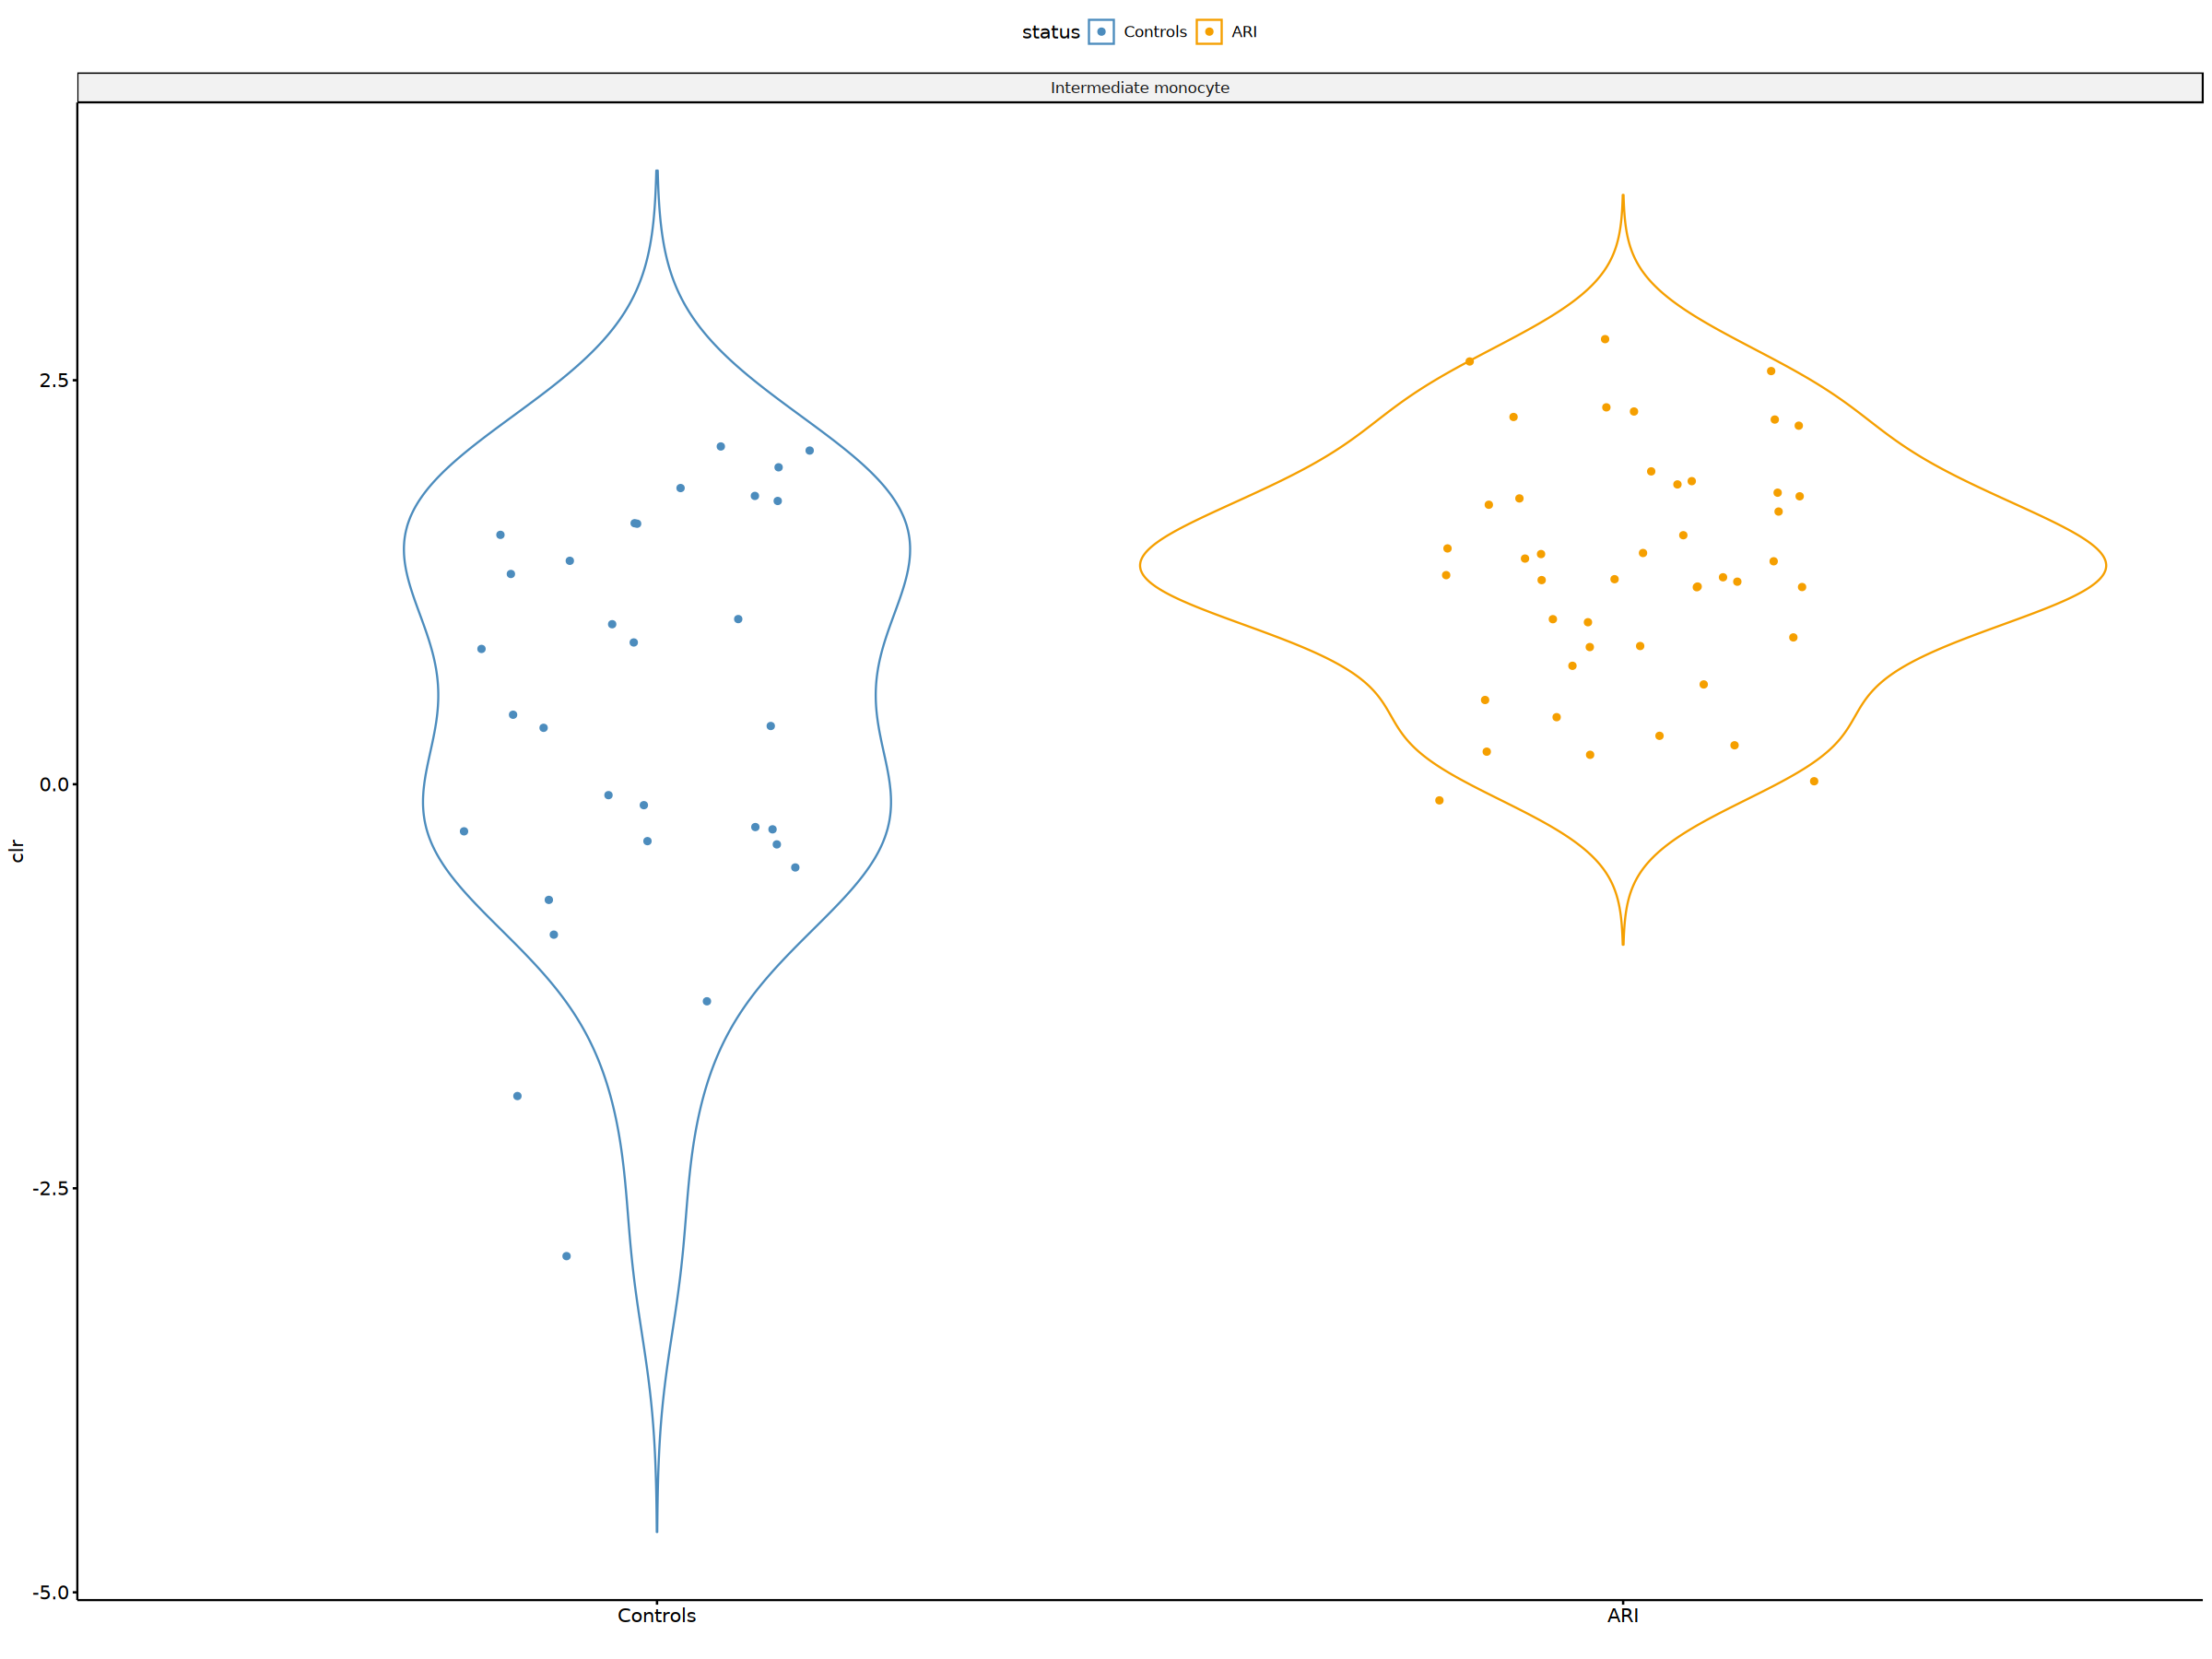

In [150]:
# plot the significant results
p1 <- aim1_aifi_l3_freq %>%  filter(AIFI_L3_new%in%sig_celltypes)%>%
    ggpubr::ggviolin(x='status', y='pseudo_clr', add = "jitter", ylab='clr', xlab='',
                     color='status', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y') 
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_sig_freq_plot.png')),
       width=4, height=4)

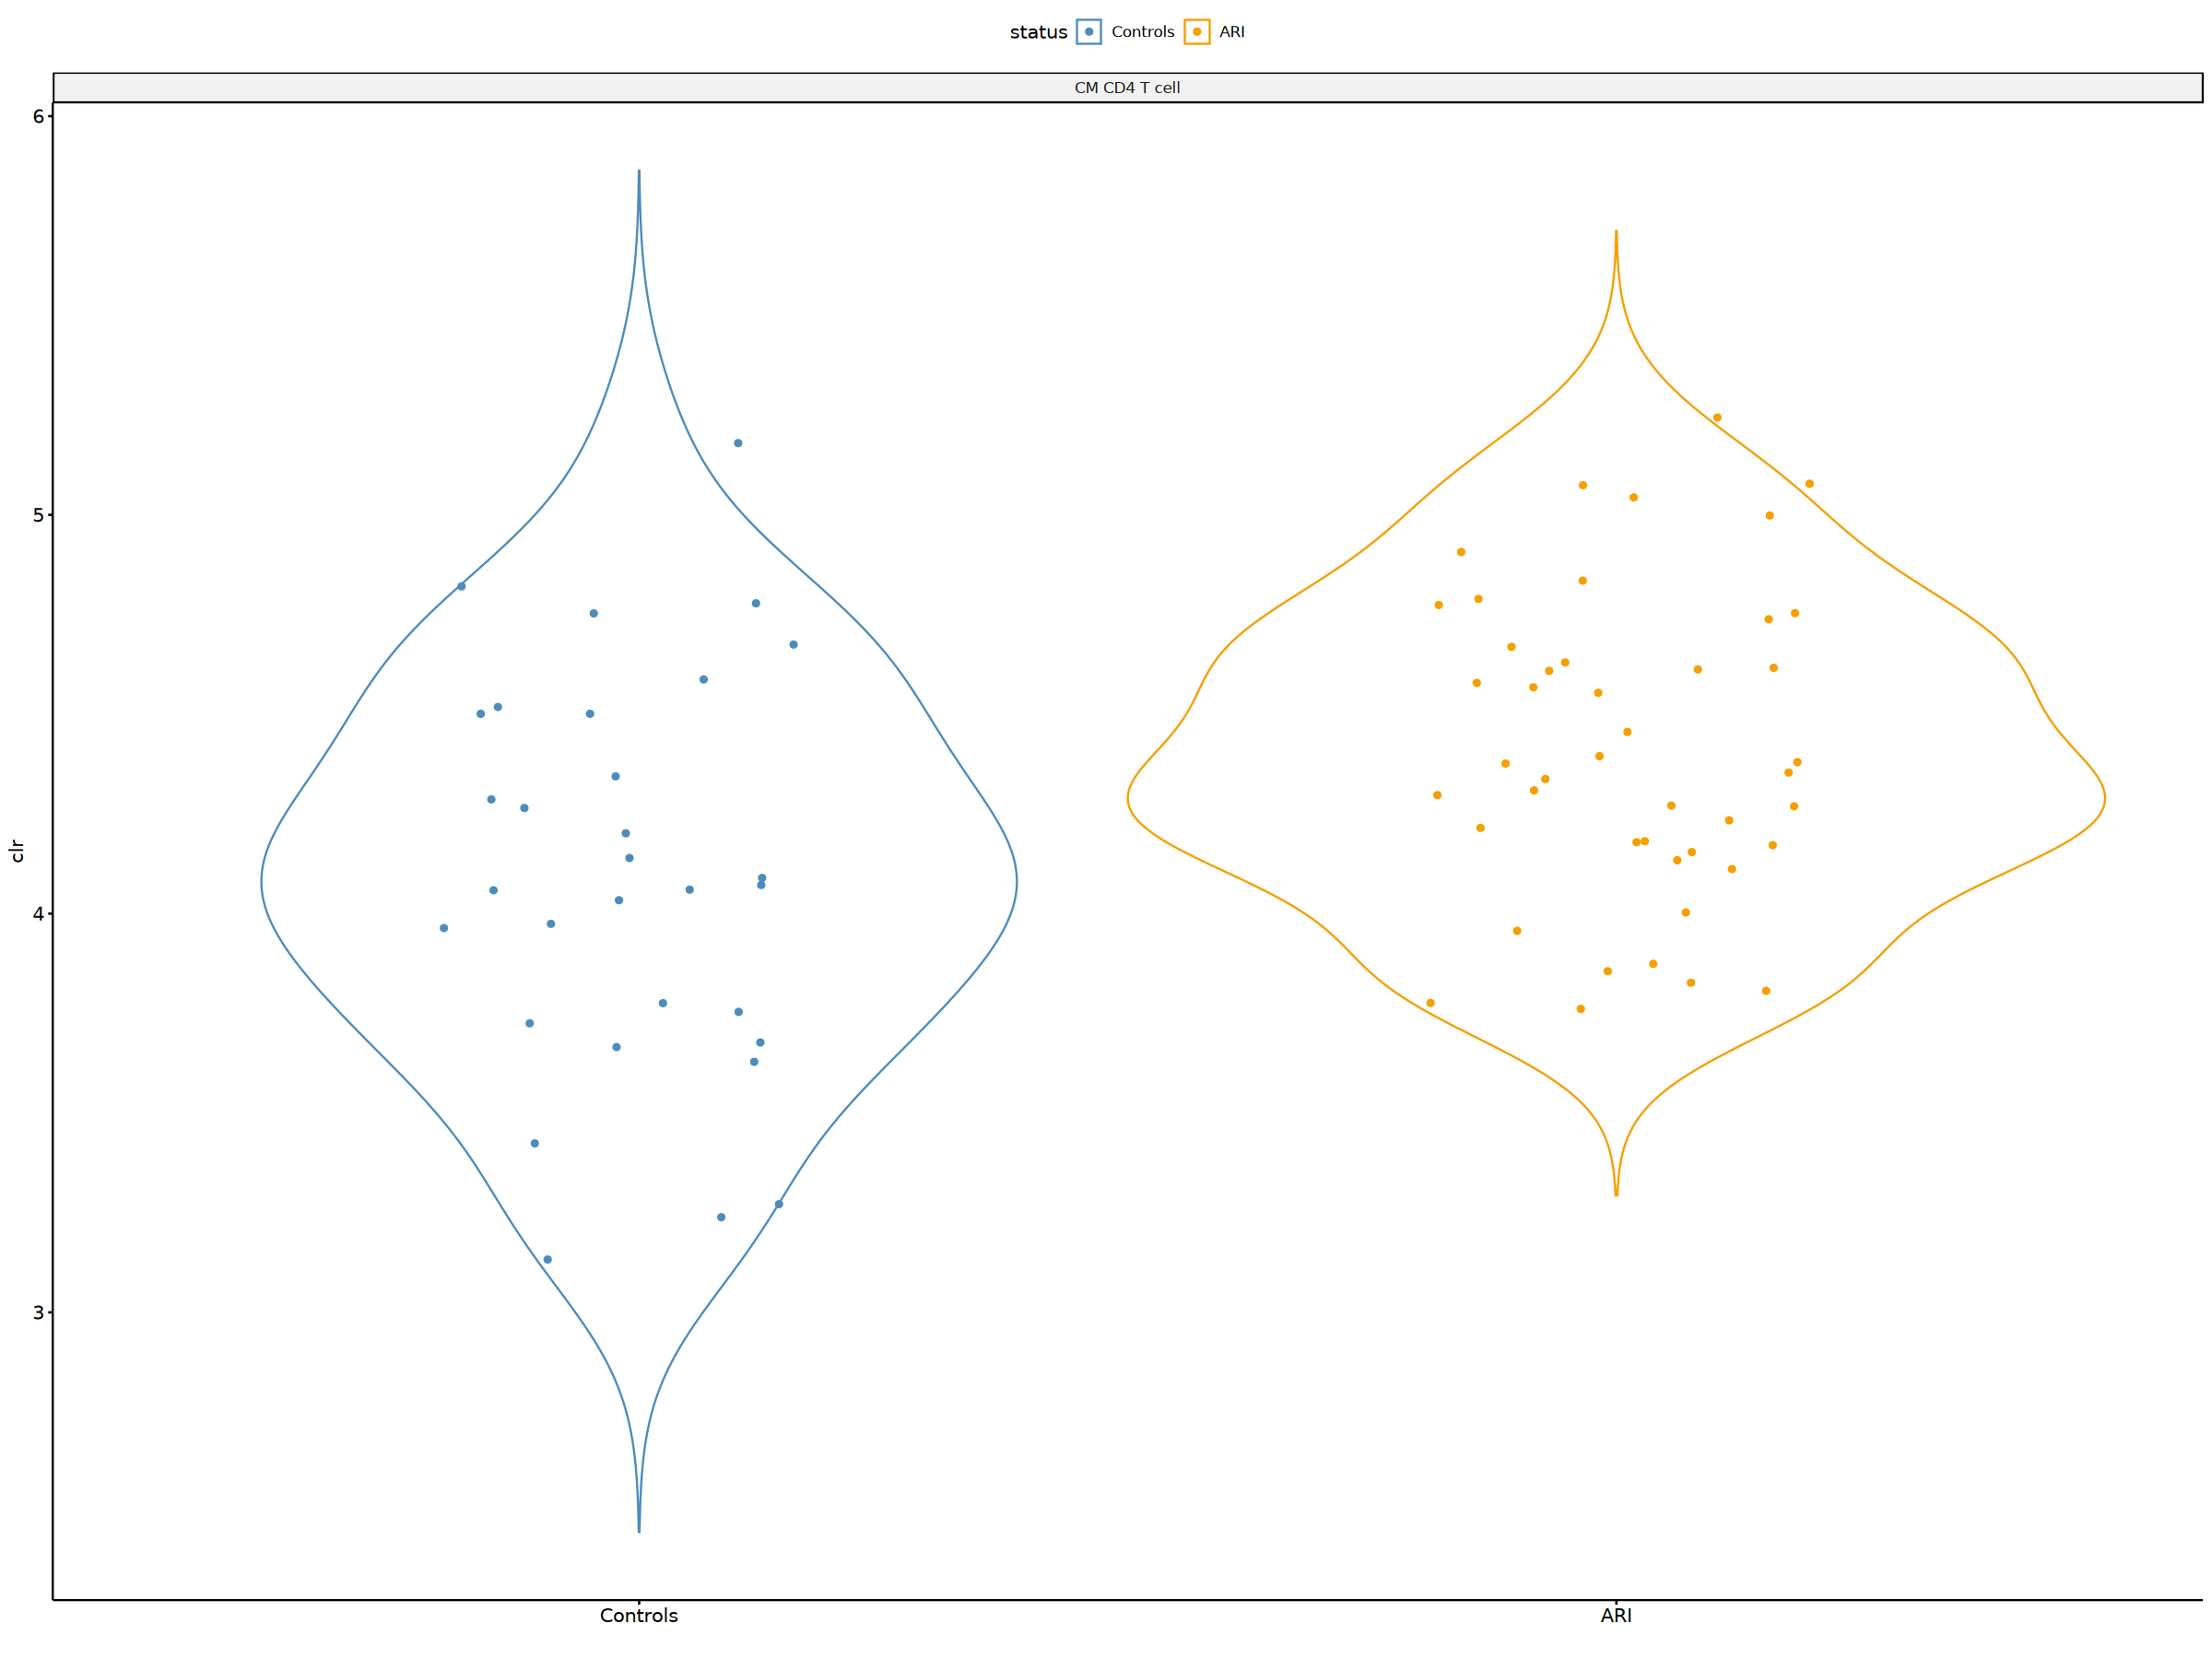

In [151]:
# plot the significant results
p1 <- aim1_aifi_l3_freq %>%  filter(AIFI_L3_new=='CM CD4 T cell')%>%
    ggpubr::ggviolin(x='status', y='pseudo_clr', add = "jitter", ylab='clr', xlab='',
                     color='status', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y') 
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_CD4CM_freq_plot.png')),
       width=4, height=4)

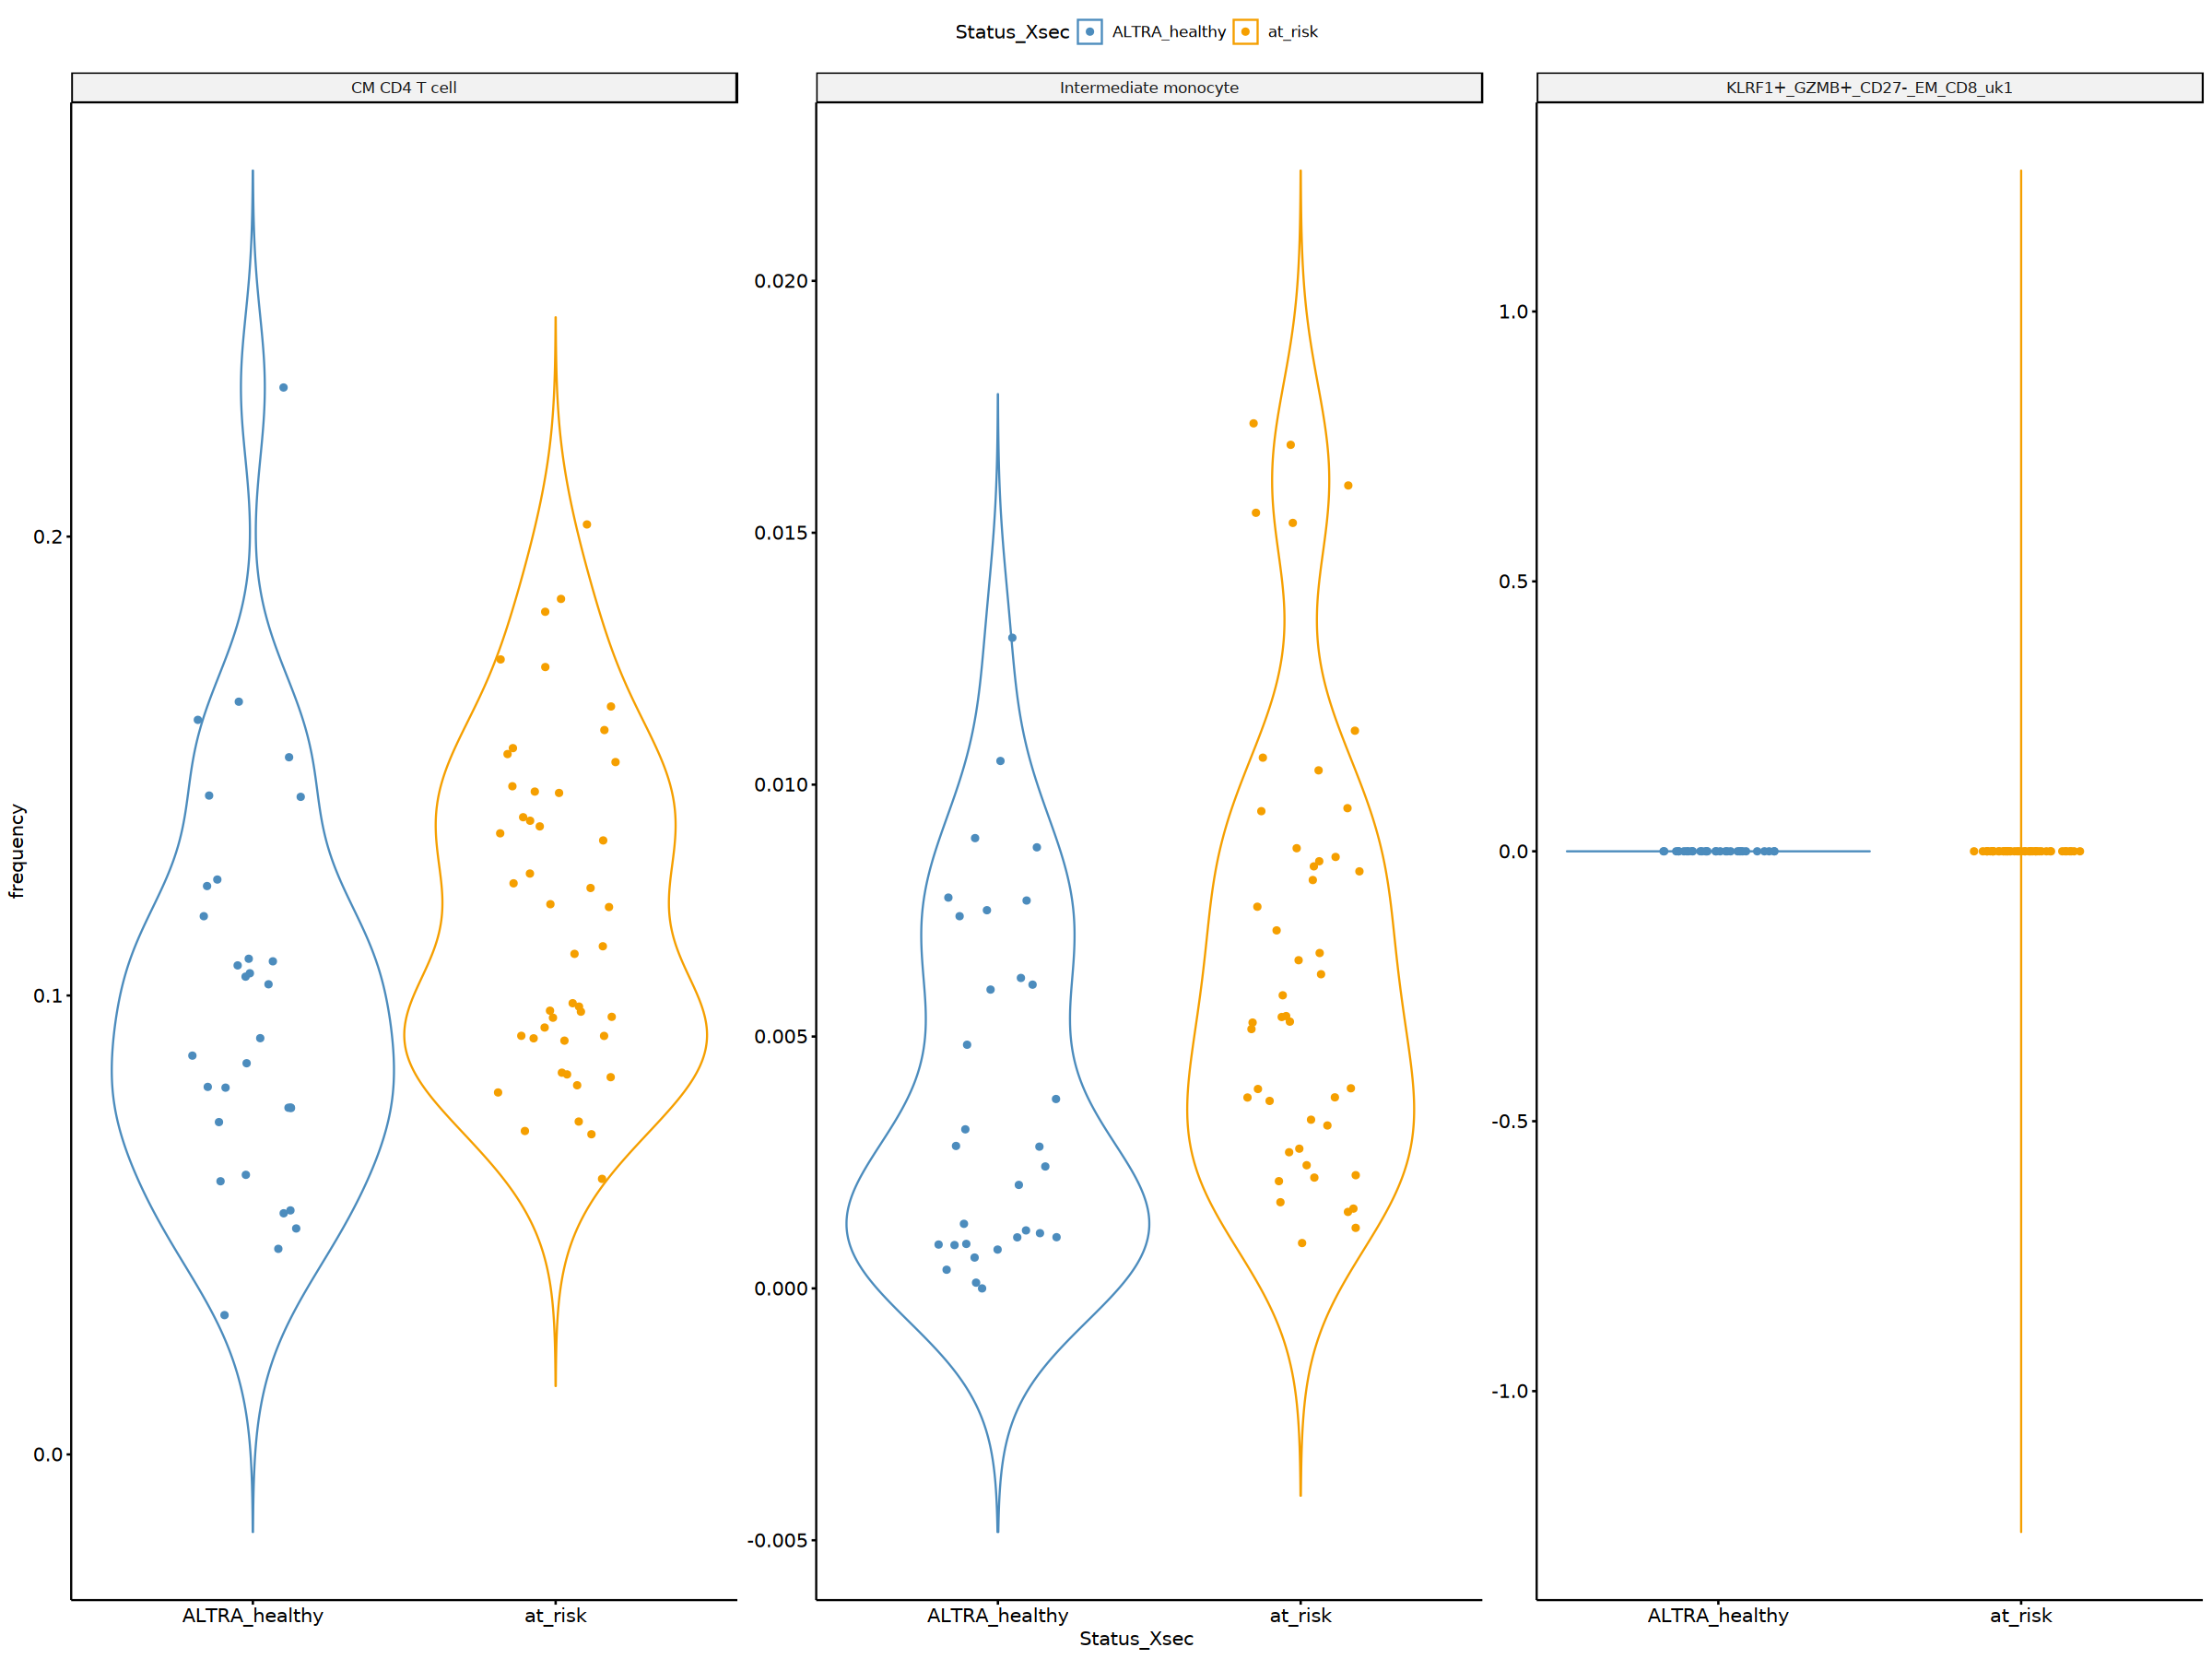

In [89]:
# plot the significant results
p1 <- da_sig %>%
    ggpubr::ggviolin(x='Status_Xsec', y='frequency', add = "jitter", 
                     color='Status_Xsec', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y')
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_sig_freq_plot.png')),
       width=12, height=4)

In [97]:
# save aim1 frequency DA results
aim1_clr_glm_status %>% write_csv(file.path(output_path, paste0(proj_name, 'AIM1_frequency_DA_results.csv')))

# AIM2

## Calculate the frequency based on the metadata

In [26]:
# load scrna file desc
aim2_scrna_meta = read_csv(file.path(meta_path, 'ALTRA_RA_Aim2_ALTRA_early_RA_vs_HCs_scrna_metadata.csv'),
                          show_col_types = FALSE)
aim2_scrna_meta%>%colnames()

[1] "lastUpdated"                         "sample.id"                          
 [3] "sample.bridgingControl"              "sample.sampleKitGuid"               
 [5] "sample.visitName"                    "sample.visitDetails"                
 [7] "sample.drawDate"                     "sample.daysSinceFirstVisit"         
 [9] "sample.diseaseStatesRecordedAtVisit" "file.id"                            
[11] "file.name"                           "file.batchID"                       
[13] "file.panel"                          "file.pool"                          
[15] "file.fileType"                       "file.majorVersion"                  
[17] "subject.id"                          "subject.biologicalSex"              
[19] "subject.birthYear"                   "subject.ethnicity"                  
[21] "subject.partnerCode"                 "subject.race"                       
[23] "subject.subjectGuid"                 "cohort.cohortGuid"                  
[25] "status"                              "age"

In [27]:
# add age to the metadata
aim2_certpro_meta <- certpro_meta %>% inner_join(select(aim2_scrna_meta, c(sample.sampleKitGuid, age)), by='sample.sampleKitGuid')
aim2_certpro_meta%>%colnames()

[1] "V1"                                  "barcodes"                           
 [3] "batch_id"                            "cell_name"                          
 [5] "cell_uuid"                           "chip_id"                            
 [7] "hto_barcode"                         "hto_category"                       
 [9] "n_genes"                             "n_mito_umis"                        
[11] "n_reads"                             "n_umis"                             
[13] "original_barcodes"                   "pbmc_sample_id"                     
[15] "pool_id"                             "well_id"                            
[17] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
[19] "subject.subjectGuid"                 "subject.biologicalSex"              
[21] "subject.race"                        "subject.ethnicity"                  
[23] "subject.birthYear"                   "sample.visitName"                   
[25] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[27] "sample.daysSinceFirstVisit"          "file.id"                            
[29] "subset_grp"                          "predicted_doublet"                  
[31] "doublet_score"                       "AIFI_L1"                            
[33] "AIFI_L1_score"                       "AIFI_L2"                            
[35] "AIFI_L2_score"                       "AIFI_L3"                            
[37] "AIFI_L3_score"                       "n_genes_by_counts"                  
[39] "log1p_n_genes_by_counts"             "total_counts"                       
[41] "log1p_total_counts"                  "pct_counts_in_top_50_genes"         
[43] "pct_counts_in_top_100_genes"         "pct_counts_in_top_200_genes"        
[45] "pct_counts_in_top_500_genes"         "total_counts_mito"                  
[47] "log1p_total_counts_mito"             "pct_counts_mito"                    
[49] "leiden_harmony_2"                    "doublets_manual"                    
[51] "AIFI_L3_new"                         "Status_Xsec"                        
[53] "Status_Long"                         "anti_ccp3_finalCombined"            
[55] "days_to_conversion"                  "BMI"                                
[57] "CMV_Status_Subj"                     "age_conv"                           
[59] "bmi_conv"                            "file.batchID"                       
[61] "status"                              "age"

In [28]:
# calculate the frequency of aim2
aim2_aifi_l3_freq <- calculate_pseudo_frequencies(aim2_certpro_meta, celltype_column = 'AIFI_L3_new',
                                             sample_id_column = 'sample.sampleKitGuid', 
                                             metadata_columns = c('subject.subjectGuid', 'subject.biologicalSex', 
                                                                  'BMI','CMV_Status_Subj',
                                                                  'status', 'age', 'file.batchID',
                                                                  'Status_Xsec'))

In [29]:
aim2_aifi_l3_freq%>%head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency
<fct>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Activated memory B cell,KT00055,1,2,13249,CU1008,Female,43.24286,Positive,early_RA,53,B002,early_RA,7.598207e-05,1.509548e-04
Activated memory B cell,KT00072,0,1,16572,CU1012,Female,24.86029,Negative,early_RA,51,B140,early_RA,0.000000e+00,6.034275e-05
Activated memory B cell,KT00109,1,2,14609,SD1003,Female,25.65487,Negative,conversion,36,B046,early_RA,6.886578e-05,1.369019e-04
Activated memory B cell,KT00447,9,10,18402,CU1032,Female,39.91053,Negative,early_RA,59,B046,early_RA,4.914273e-04,5.434192e-04
Activated memory B cell,KT00474,3,4,14360,CU1043,Female,31.46320,Negative,early_RA,61,B087,early_RA,2.102018e-04,2.785515e-04
Activated memory B cell,KT00777,1,2,7698,SD1012,Male,30.90516,Negative,early_RA,38,B122,early_RA,1.314060e-04,2.598077e-04


In [30]:
aim2_aifi_l3_freq%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)%>%
    group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
early_RA,25


In [31]:
# perform clr transformation
aim2_aifi_l3_freq <- FreqClrTran(aim2_aifi_l3_freq, freq_col='pseudo_frequency',
                                   celltype_col='AIFI_L3_new', clr_name='pseudo_clr',
                          sample_col='sample.sampleKitGuid')

In [32]:
# save aim2 frequency table
aim2_aifi_l3_freq%>%write_csv(file.path(output_path, paste0(proj_name, 'AIM2_frequency_table.csv')))

## run stats

In [37]:
aim2_aifi_l3_freq%>%head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00055,1,2,13249,CU1008,Female,43.24286,Positive,early_RA,53,B002,early_RA,7.598207e-05,1.509548e-04,-2.3414046
Activated memory B cell,KT00072,0,1,16572,CU1012,Female,24.86029,Negative,early_RA,51,B140,early_RA,0.000000e+00,6.034275e-05,-3.0591005
Activated memory B cell,KT00109,1,2,14609,SD1003,Female,25.65487,Negative,conversion,36,B046,early_RA,6.886578e-05,1.369019e-04,-2.5785648
Activated memory B cell,KT00447,9,10,18402,CU1032,Female,39.91053,Negative,early_RA,59,B046,early_RA,4.914273e-04,5.434192e-04,-0.9250044
Activated memory B cell,KT00474,3,4,14360,CU1043,Female,31.46320,Negative,early_RA,61,B087,early_RA,2.102018e-04,2.785515e-04,-1.5263872
Activated memory B cell,KT00777,1,2,7698,SD1012,Male,30.90516,Negative,early_RA,38,B122,early_RA,1.314060e-04,2.598077e-04,-1.7510859


In [38]:
aim2_aifi_l3_freq%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)%>%group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
early_RA,25


In [100]:
# filter cell type that are too rare to do analysis
rare_celltype <- aim2_aifi_l3_freq %>% dplyr::filter(counts==0)%>%
    group_by(AIFI_L3_new)%>%tally()%>% arrange(desc(n))%>%
    filter(n>(31+25)/2)%>%
    pull(AIFI_L3_new)
rare_celltype

[1] "Activated memory B cell_uk1"    "KLRF1+_GZMB+_CD27-_EM_CD8_uk1" 
[3] "Early memory B cell_uk1"        "KLRF1-_GZMB+_CD27-_mem_CD4_uk1"
[5] "BaEoMaP cell"                   "KLRF1-_GZMB+_CD27-_EM_CD8_uk1" 
[7] "ILC_uk1"                        "Prolif_T_uk1"                  
[9] "ASDC_uk1_B"

In [101]:
# run statistic test
freq_stats_wilcox <- aim2_aifi_l3_freq %>%  filter(!AIFI_L3_new%in%rare_celltype)%>%
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'early_RA')))%>%
    group_by(AIFI_L3_new) %>%
    rstatix::wilcox_test(pseudo_clr ~ Status_Xsec, paired = FALSE) %>%
    rstatix::adjust_pvalue(method = "BH") %>%
    rstatix::add_significance("p.adj") 
freq_stats_wilcox%>%arrange(p.adj)%>%head(10)

AIFI_L3_new,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
ASDC,pseudo_clr,ALTRA_healthy,early_RA,31,25,542,0.0104,0.5490500,ns
Proliferating T cell,pseudo_clr,ALTRA_healthy,early_RA,31,25,239,0.0139,0.5490500,ns
CLP cell,pseudo_clr,ALTRA_healthy,early_RA,31,25,516,0.0341,0.8979667,ns
ISG+ memory CD8 T cell,pseudo_clr,ALTRA_healthy,early_RA,31,25,508,0.0474,0.9361500,ns
CM CD4 T cell,pseudo_clr,ALTRA_healthy,early_RA,31,25,285,0.0929,0.9601538,ns
CM CD4 T cell_uk1_CD8,pseudo_clr,ALTRA_healthy,early_RA,31,25,297,0.1390,0.9601538,ns
Core CD16 monocyte,pseudo_clr,ALTRA_healthy,early_RA,31,25,301,0.1580,0.9601538,ns
Erythrocyte,pseudo_clr,ALTRA_healthy,early_RA,31,25,478,0.1390,0.9601538,ns
GZMK+ CD27+ EM CD8 T cell_uk1_gdt,pseudo_clr,ALTRA_healthy,early_RA,31,25,476,0.1480,0.9601538,ns


In [102]:
# run statistic model for CLR
aim2_clr_glm <- aim2_aifi_l3_freq %>% filter(!AIFI_L3_new%in%rare_celltype)%>%
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'early_RA')))%>%
    group_by(AIFI_L3_new) %>% 
    group_modify(~RunGlmFreq(.x, formula='pseudo_clr ~ age + subject.biologicalSex + BMI + Status_Xsec', 
                           cell_type=.y$AIFI_L3_new))

In [103]:
aim2_clr_glm_status <- aim2_clr_glm %>% filter(term=='Status_Xsecearly_RA') %>% ungroup()%>%
    rstatix::adjust_pvalue(method = "BH")%>% arrange(p.value.adj)

In [104]:
aim2_clr_glm_status%>%head(10)

AIFI_L3_new,term,estimate,std.error,statistic,p.value,cell_type,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
ASDC,Status_Xsecearly_RA,-0.4714002,0.1610827,-2.926449,0.005146191,ASDC,0.3704168
Proliferating T cell,Status_Xsecearly_RA,0.3992665,0.1477448,2.702407,0.009377642,Proliferating T cell,0.3704168
Core CD16 monocyte,Status_Xsecearly_RA,0.5587234,0.2400176,2.327843,0.024007445,Core CD16 monocyte,0.4741470
SOX4+ naive CD8 T cell,Status_Xsecearly_RA,-0.6474096,0.2661405,-2.432585,0.018612400,SOX4+ naive CD8 T cell,0.4741470
Type 2 polarized memory B cell,Status_Xsecearly_RA,0.3733482,0.1714661,2.177388,0.034197772,Type 2 polarized memory B cell,0.5403248
CD8aa,Status_Xsecearly_RA,-0.4064498,0.2121069,-1.916250,0.061058811,CD8aa,0.6024935
CLP cell,Status_Xsecearly_RA,-0.3758575,0.1948991,-1.928472,0.059483932,CLP cell,0.6024935
CM CD4 T cell,Status_Xsecearly_RA,0.2307095,0.1239751,1.860934,0.068638498,CM CD4 T cell,0.6024935
ISG+ memory CD8 T cell,Status_Xsecearly_RA,-0.5137027,0.2641129,-1.945011,0.057408125,ISG+ memory CD8 T cell,0.6024935


In [105]:
# save aim2 frequency DA results
aim2_clr_glm_status %>% write_csv(file.path(output_path, paste0(proj_name, 'AIM2_frequency_DA_results.csv')))

# AIM3 longitudinal DA analysis 

In [5]:
# load scrna file desc
aim3_scrna_meta = read_csv(file.path(meta_path, 'ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv'),
                          show_col_types = FALSE)
aim3_scrna_meta%>%colnames()

[1] "lastUpdated"                         "sample.id"                          
 [3] "sample.bridgingControl"              "sample.sampleKitGuid"               
 [5] "sample.visitName"                    "sample.visitDetails"                
 [7] "sample.drawDate"                     "sample.daysSinceFirstVisit"         
 [9] "sample.diseaseStatesRecordedAtVisit" "file.id"                            
[11] "file.name"                           "file.batchID"                       
[13] "file.panel"                          "file.pool"                          
[15] "file.fileType"                       "file.majorVersion"                  
[17] "subject.id"                          "subject.biologicalSex"              
[19] "subject.birthYear"                   "subject.ethnicity"                  
[21] "subject.partnerCode"                 "subject.race"                       
[23] "subject.subjectGuid"                 "cohort.cohortGuid"                  
[25] "file.userTags.details"               "file.userTags.group"                
[27] "file.userTags.name"                  "file.userTags.origin"               
[29] "file.userTags.other"                 "file.userTags.version"              
[31] "days_to_conversion"                  "status"                             
[33] "age"

In [45]:
# add age to the metadata
aim3_certpro_meta <- certpro_meta %>% inner_join(select(aim3_scrna_meta, c(sample.sampleKitGuid, age)), by='sample.sampleKitGuid')
aim3_certpro_meta%>%colnames()

[1] "V1"                                  "barcodes"                           
 [3] "batch_id"                            "cell_name"                          
 [5] "cell_uuid"                           "chip_id"                            
 [7] "hto_barcode"                         "hto_category"                       
 [9] "n_genes"                             "n_mito_umis"                        
[11] "n_reads"                             "n_umis"                             
[13] "original_barcodes"                   "pbmc_sample_id"                     
[15] "pool_id"                             "well_id"                            
[17] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
[19] "subject.subjectGuid"                 "subject.biologicalSex"              
[21] "subject.race"                        "subject.ethnicity"                  
[23] "subject.birthYear"                   "sample.visitName"                   
[25] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[27] "sample.daysSinceFirstVisit"          "file.id"                            
[29] "subset_grp"                          "predicted_doublet"                  
[31] "doublet_score"                       "AIFI_L1"                            
[33] "AIFI_L1_score"                       "AIFI_L2"                            
[35] "AIFI_L2_score"                       "AIFI_L3"                            
[37] "AIFI_L3_score"                       "n_genes_by_counts"                  
[39] "log1p_n_genes_by_counts"             "total_counts"                       
[41] "log1p_total_counts"                  "pct_counts_in_top_50_genes"         
[43] "pct_counts_in_top_100_genes"         "pct_counts_in_top_200_genes"        
[45] "pct_counts_in_top_500_genes"         "total_counts_mito"                  
[47] "log1p_total_counts_mito"             "pct_counts_mito"                    
[49] "leiden_harmony_2"                    "doublets_manual"                    
[51] "AIFI_L3_new"                         "Status_Xsec"                        
[53] "Status_Long"                         "anti_ccp3_finalCombined"            
[55] "days_to_conversion"                  "BMI"                                
[57] "CMV_Status_Subj"                     "age_conv"                           
[59] "bmi_conv"                            "file.batchID"                       
[61] "status"                              "age"

In [46]:
# calculate the frequency of AIM1
aim3_l3_freq <- calculate_pseudo_frequencies(aim3_certpro_meta, celltype_column = 'AIFI_L3_new',
                                             sample_id_column = 'sample.sampleKitGuid', 
                                             metadata_columns = c('subject.subjectGuid', 'subject.biologicalSex', 
                                                                  'age_conv','bmi_conv','CMV_Status_Subj', 
                                                                  'status', 'file.batchID',
                                                                  'Status_Xsec', 'Status_Long', 'days_to_conversion'))

In [47]:
aim3_l3_freq%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)%>%
    group_by(Status_Long)%>%tally()

Status_Long,n
<chr>,<int>
conversion,10
pre,55


In [48]:
# perform clr transformation
aim3_l3_freq <- FreqClrTran(aim3_l3_freq, freq_col='pseudo_frequency',
                                   celltype_col='AIFI_L3_new', clr_name='pseudo_clr',
                          sample_col='sample.sampleKitGuid')

In [49]:
# save aim3 frequency table
aim3_l3_freq%>%write_csv(file.path(output_path, paste0(proj_name, 'AIM3_frequency_table.csv')))

In [107]:
# filter cell type that are too rare to do analysis
rare_celltype <- aim3_l3_freq %>% dplyr::filter(counts==0)%>%
    group_by(AIFI_L3_new)%>%tally()%>% arrange(desc(n))%>%
    filter(n>65/2)%>%
    pull(AIFI_L3_new)
rare_celltype

[1] "T2MBC_uk1"                      "KLRF1-_GZMB+_CD27-_mem_CD4_uk1"
[3] "Early memory B cell_uk1"        "KLRF1-_GZMB+_CD27-_EM_CD8_uk1" 
[5] "ILC_uk1"                        "BaEoMaP cell"                  
[7] "Prolif_T_uk1"

In [51]:
aim3_l3_freq%>%colnames()

[1] "AIFI_L3_new"           "sample.sampleKitGuid"  "counts"               
 [4] "pseudo_counts"         "pseudo_total_counts"   "subject.subjectGuid"  
 [7] "subject.biologicalSex" "age_conv"              "bmi_conv"             
[10] "CMV_Status_Subj"       "status"                "file.batchID"         
[13] "Status_Xsec"           "Status_Long"           "days_to_conversion"   
[16] "frequency"             "pseudo_frequency"      "pseudo_clr"

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


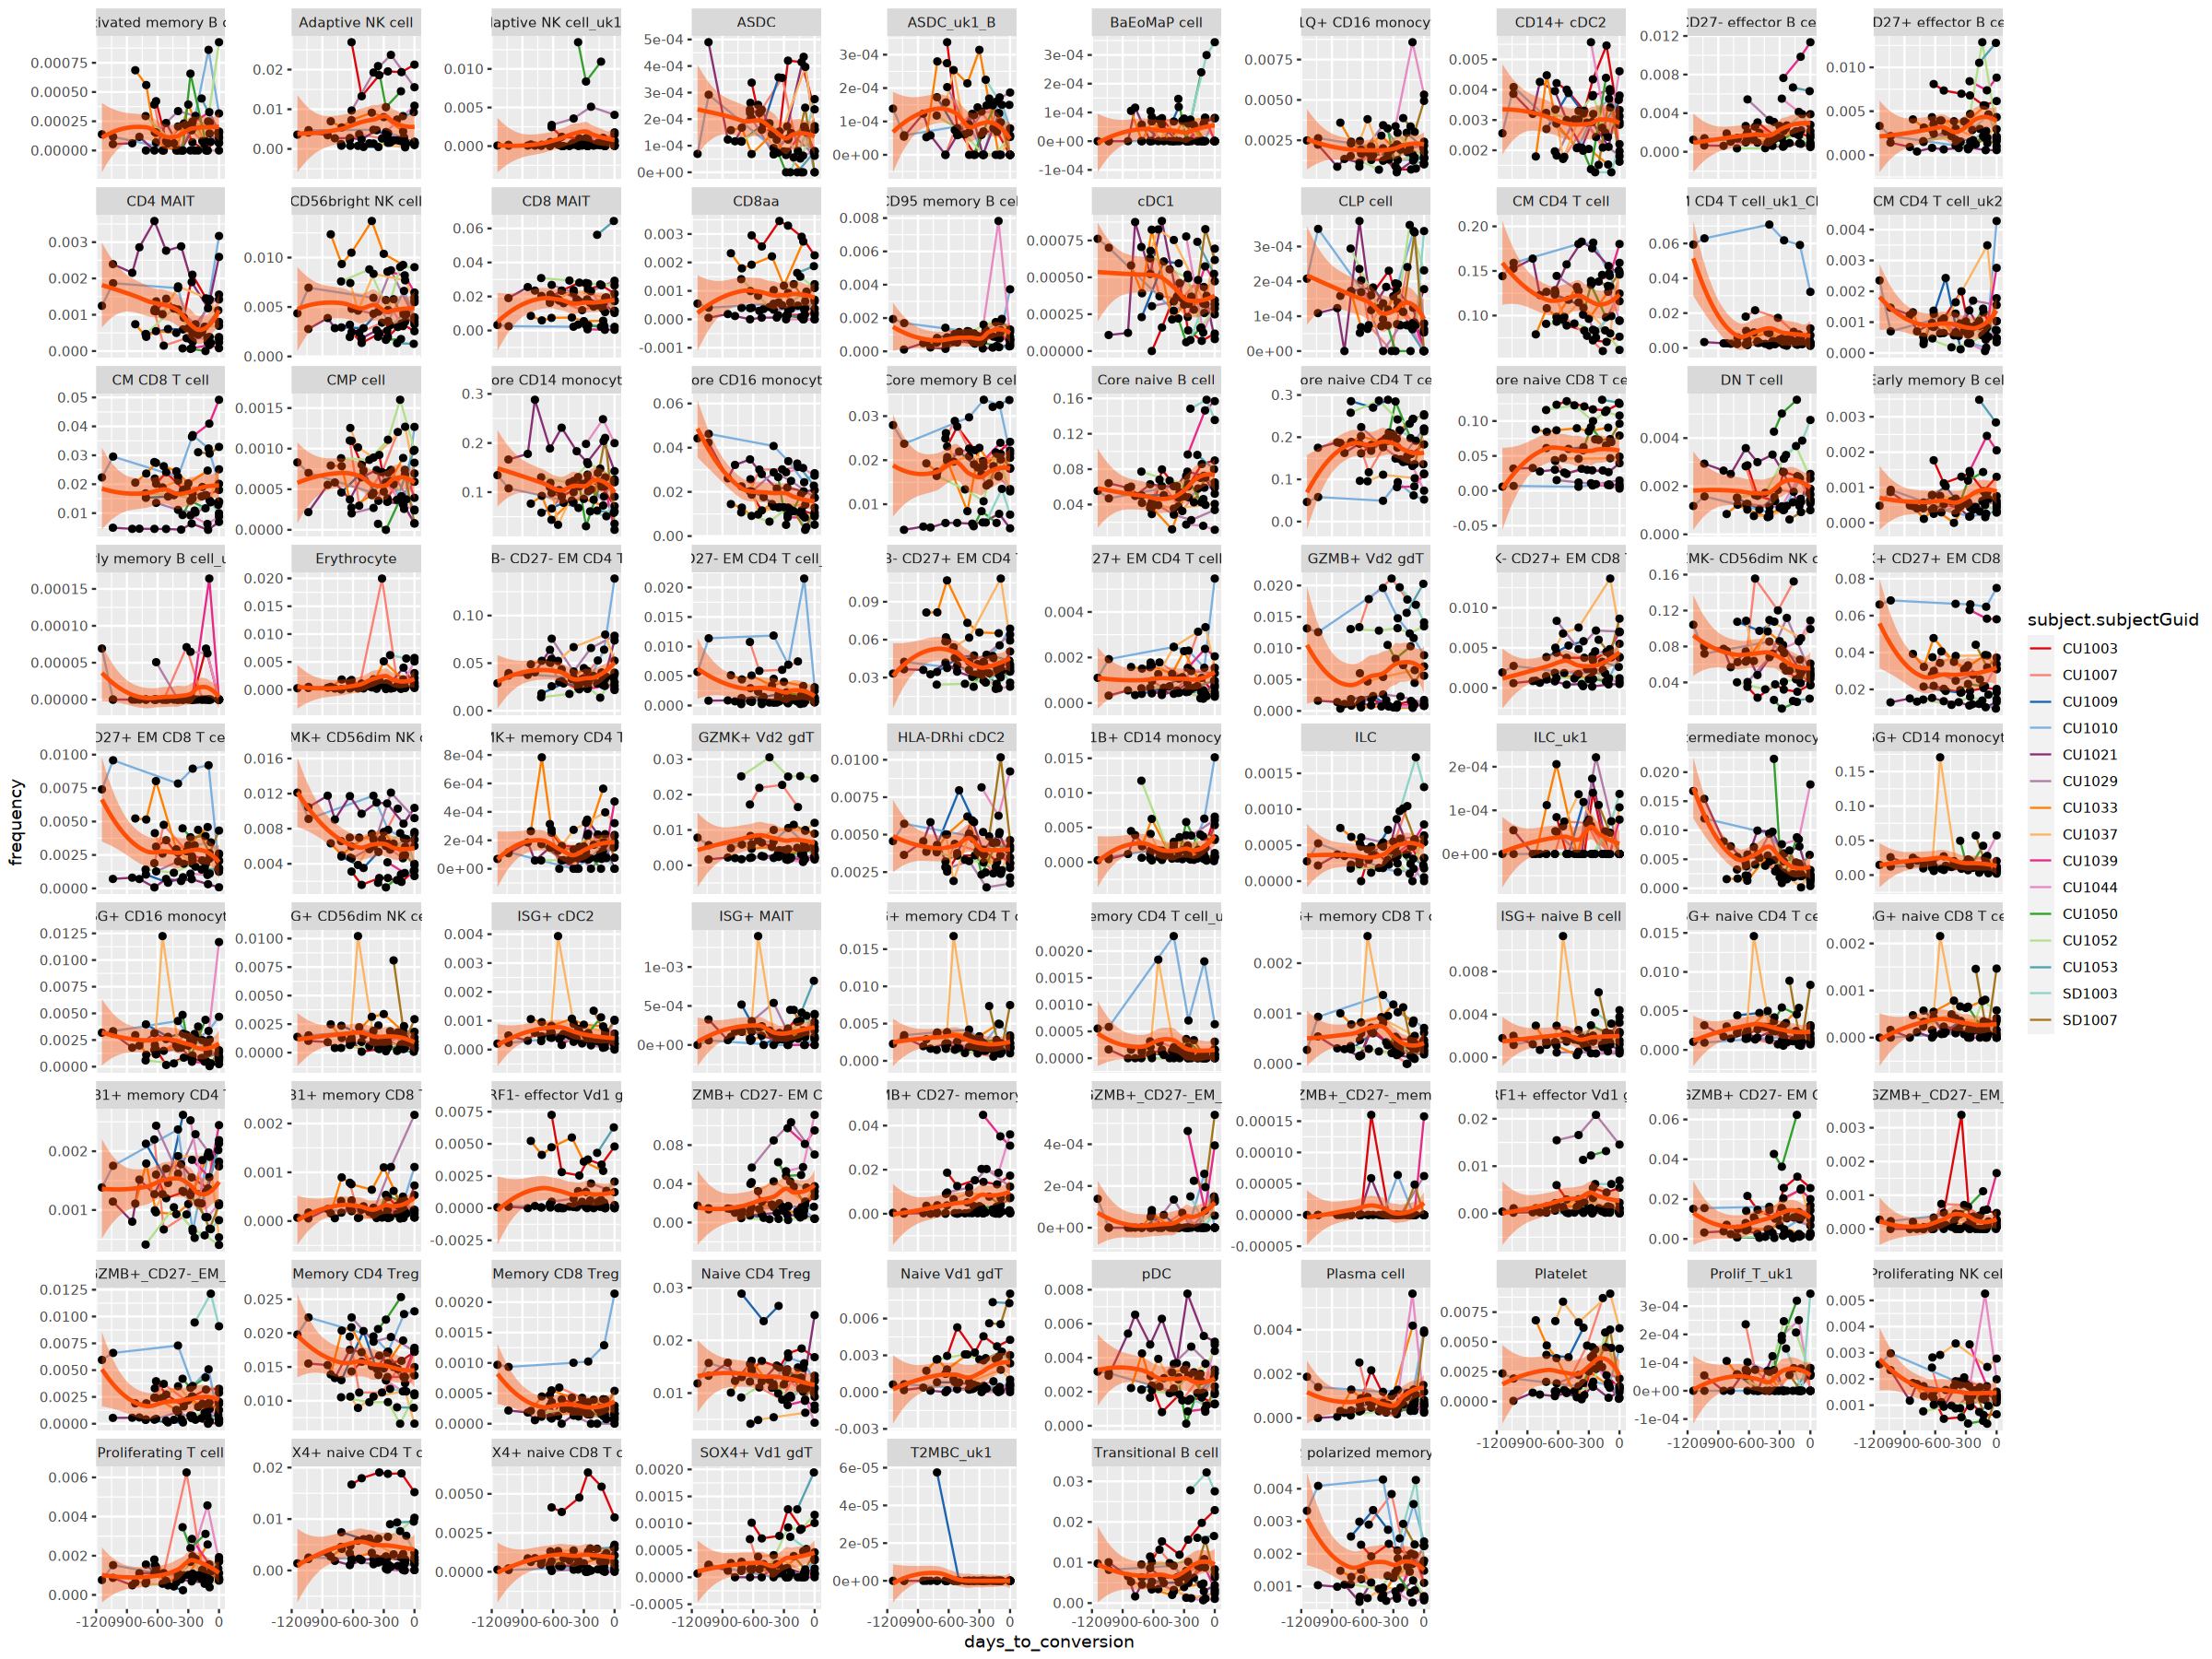

In [52]:
options(repr.plot.width = 20, repr.plot.height = 15)
# plot frequency
p1<-aim3_l3_freq %>%  ggplot(aes(x=days_to_conversion, y=`frequency`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point()+ 
    stat_smooth(
  color = "#FC4E07", fill = "#FC4E07",
  method = "loess"
  ) + facet_wrap(vars(AIFI_L3_new), scales = 'free_y') + scale_color_manual(values = cluster_colors)
p1
ggsave(file.path(fig_path, paste0(proj_name, 
                                  '_aim3_frequency.png')), width =18, height=12)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


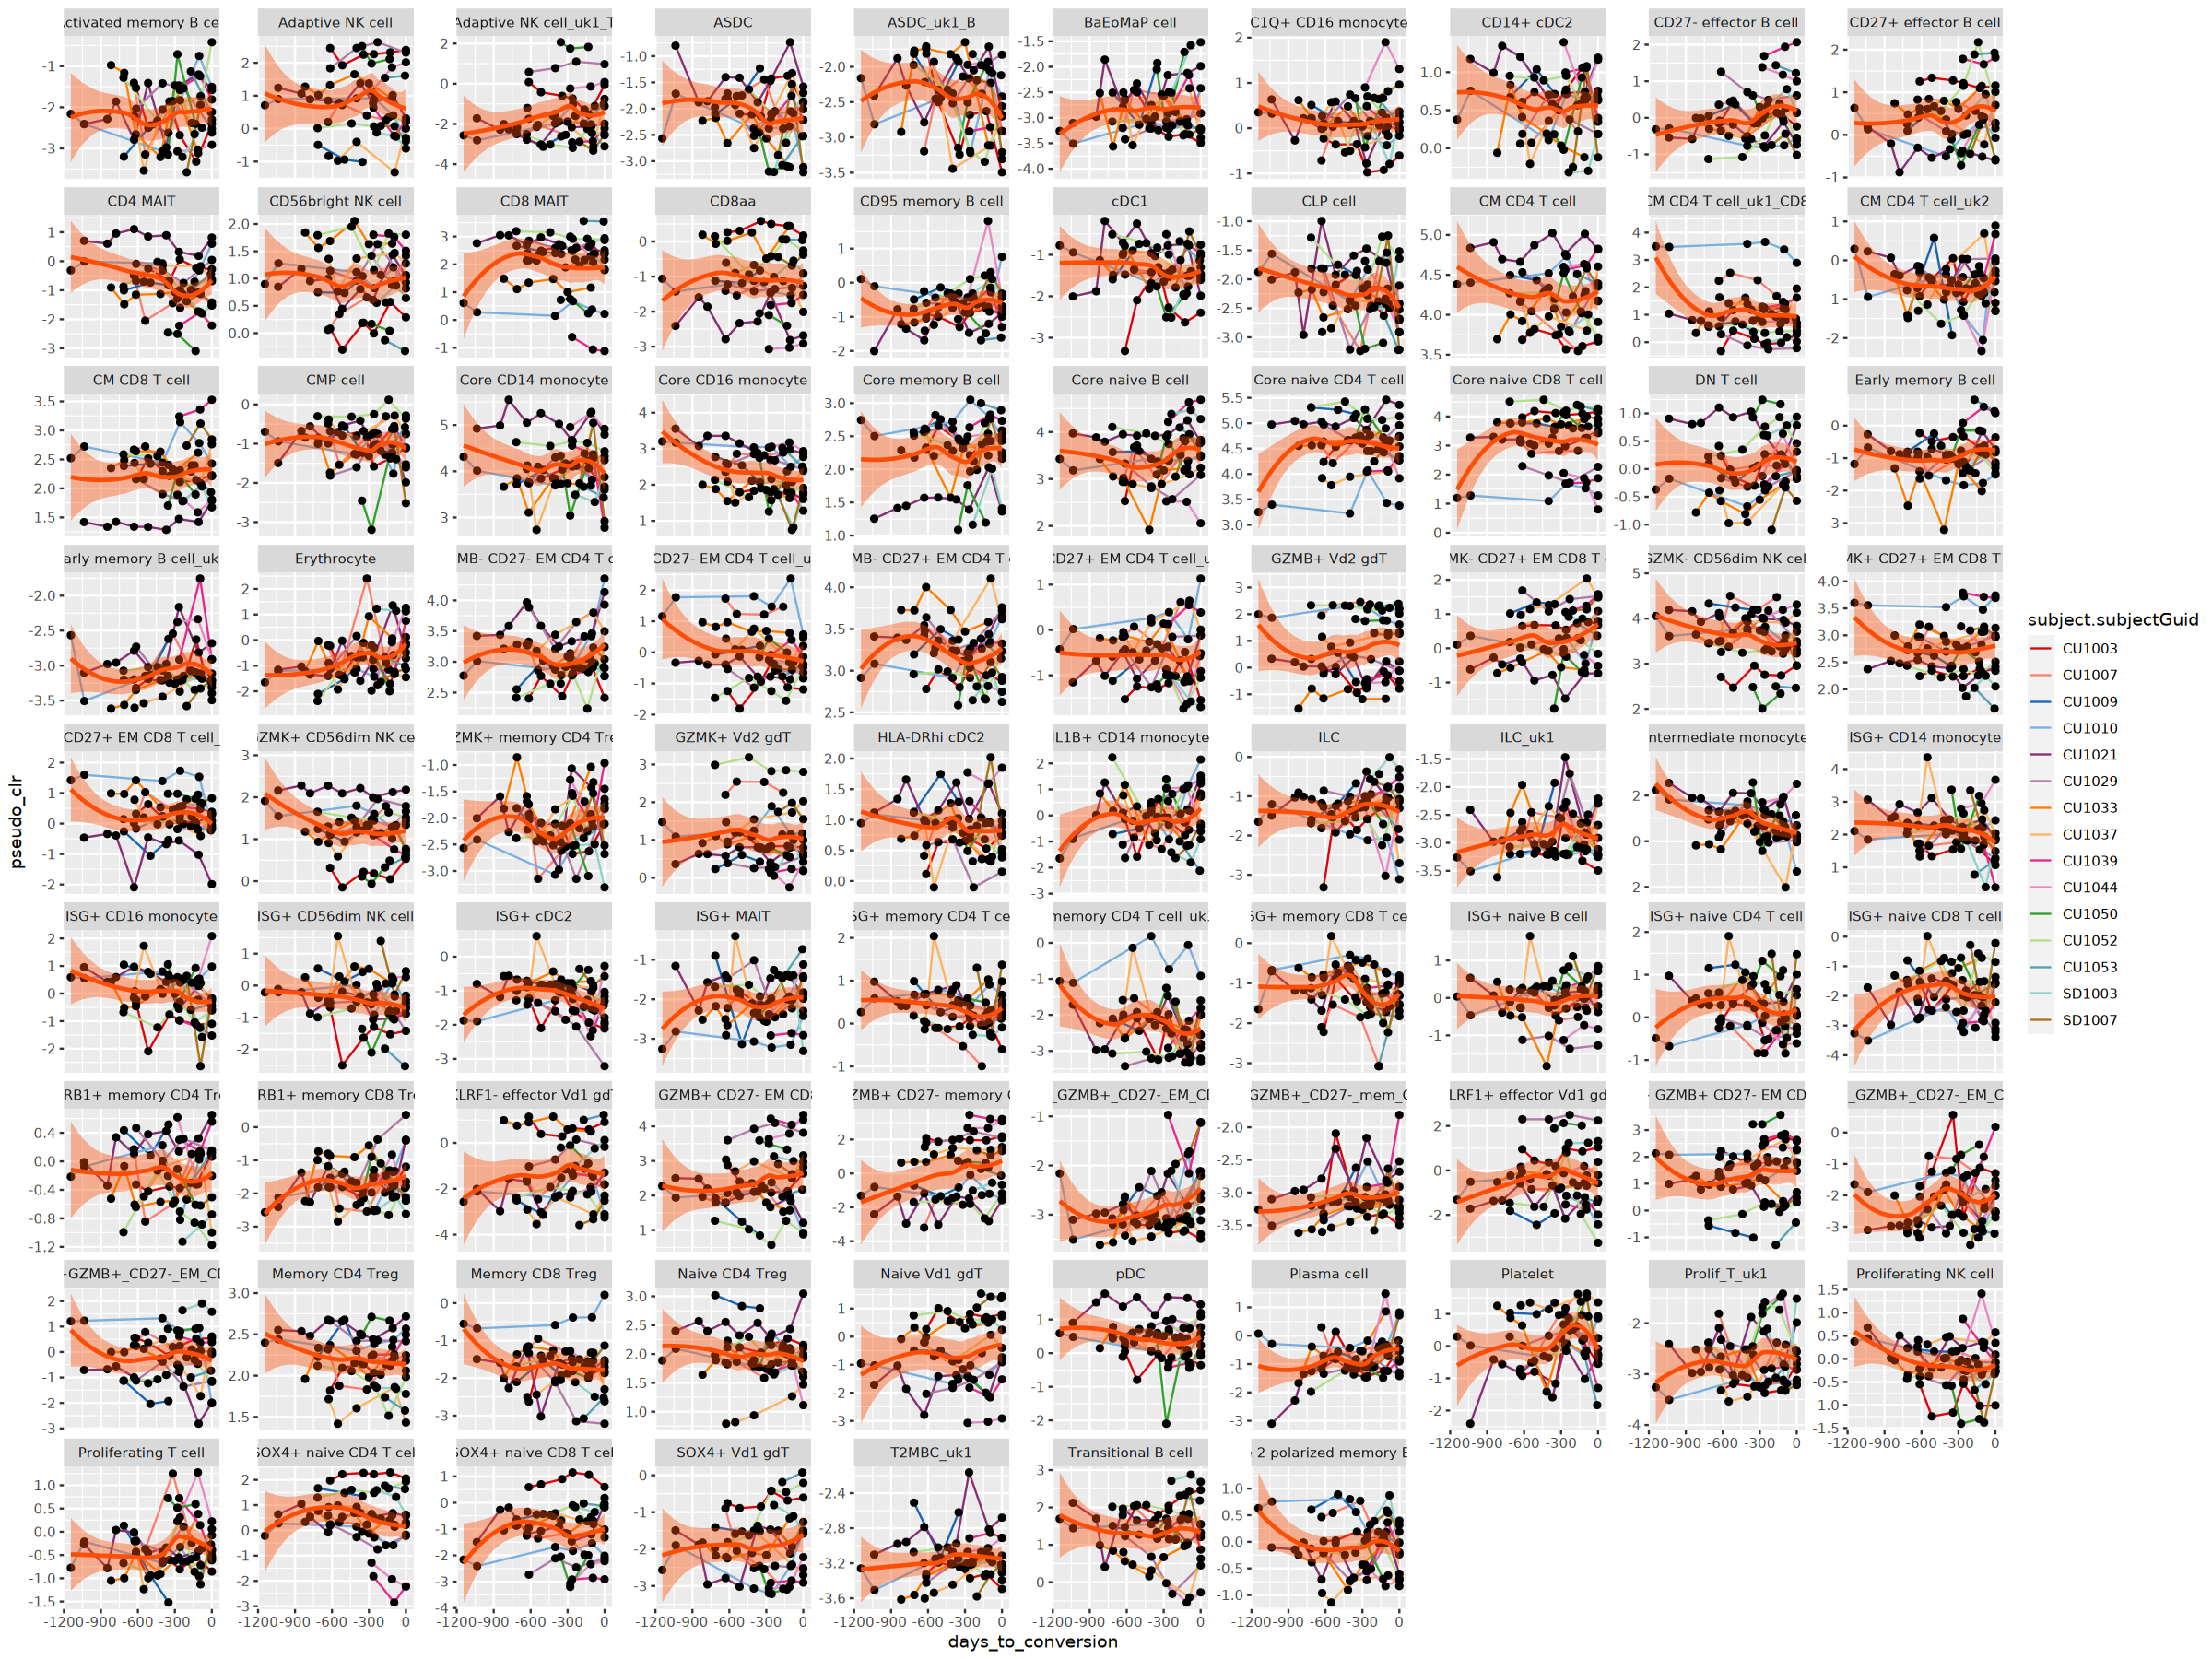

In [53]:
options(repr.plot.width = 20, repr.plot.height = 15)
p2 <- aim3_l3_freq %>% ggplot(aes(x=days_to_conversion, y=`pseudo_clr`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point()+ 
    stat_smooth(
  color = "#FC4E07", fill = "#FC4E07",
  method = "loess"
  ) + facet_wrap(vars(AIFI_L3_new), scales = 'free_y') + scale_color_manual(values = cluster_colors)
p2
ggsave(file.path(fig_path, paste0(proj_name, '_aim3_clr.png')), 
       width =18, height=12)

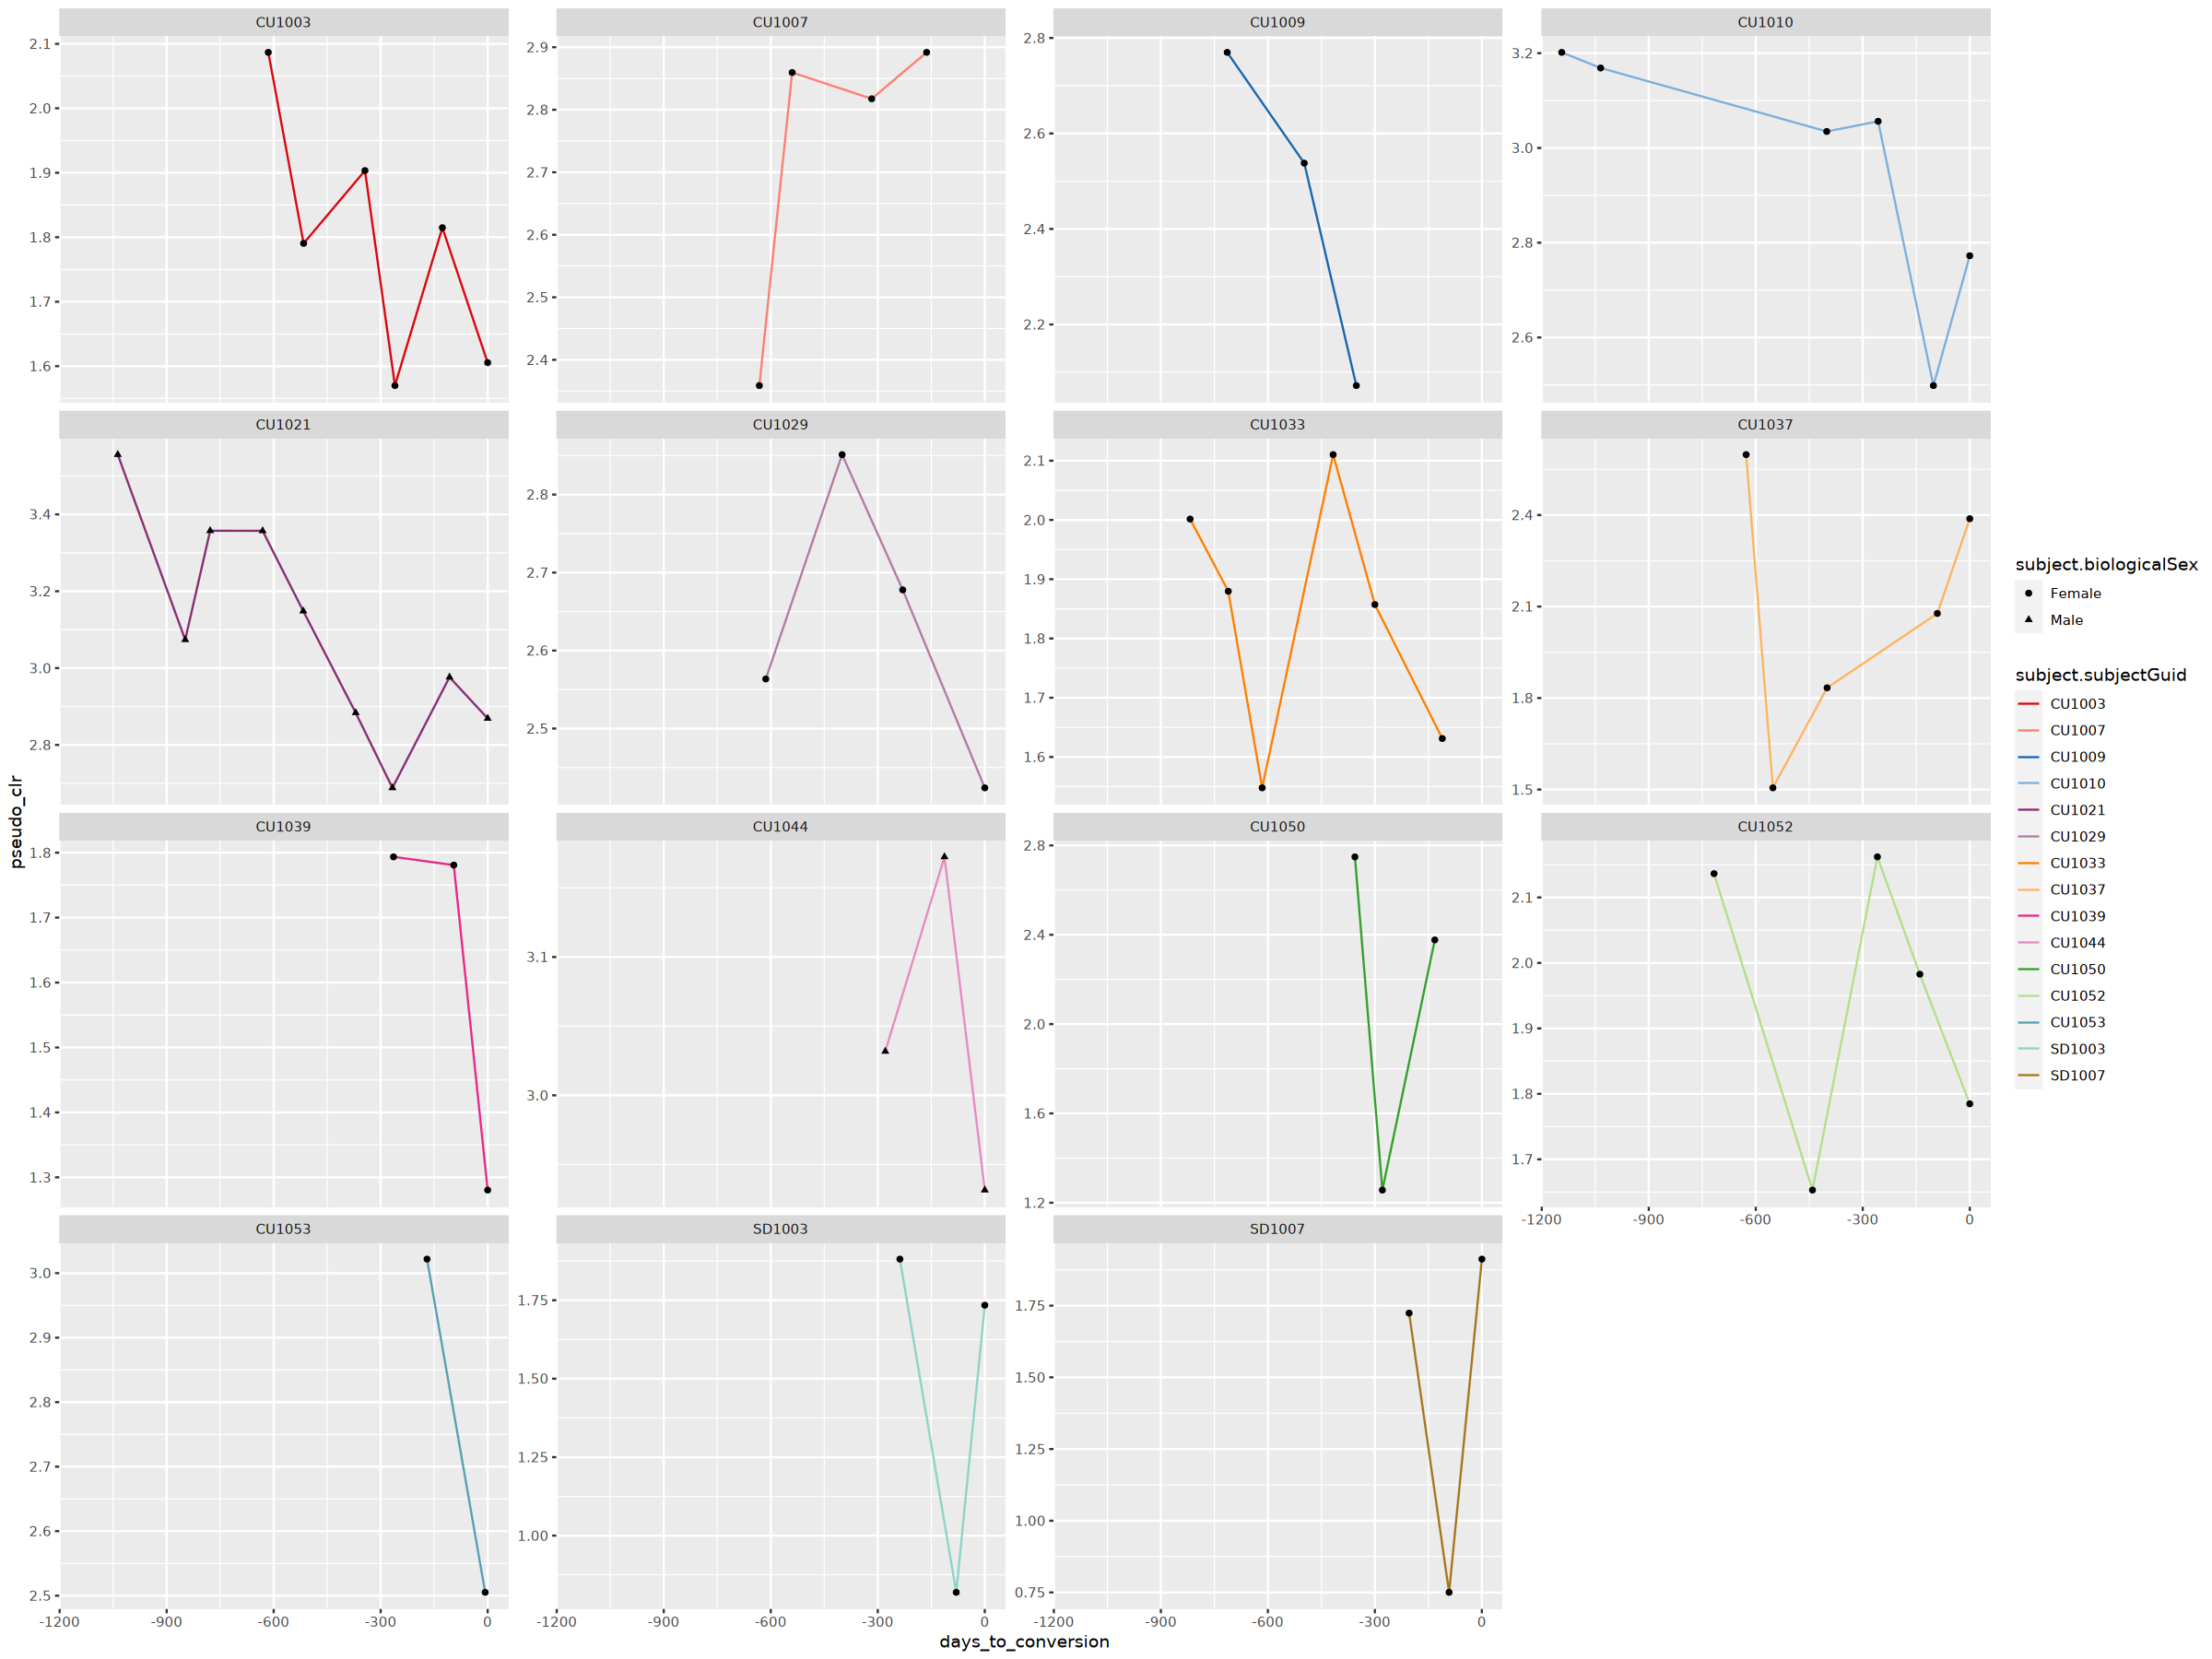

In [54]:
# take one cell type to model first
cd16mono_freq <- aim3_l3_freq %>% filter(AIFI_L3_new=='Core CD16 monocyte')
# cd16mono_freq
p3<-cd16mono_freq %>%  ggplot(aes(x=days_to_conversion, y=`pseudo_clr`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point(aes(shape=subject.biologicalSex)) + 
    facet_wrap(vars(subject.subjectGuid), scales = 'free_y') + 
    scale_color_manual(values = cluster_colors)
p3

## linear mixed model

In [108]:
# subset the dataset to -750 days in only female
aim3_l3_freq_fe <- aim3_l3_freq %>% filter(days_to_conversion>= (-750) & 
                        subject.biologicalSex=='Female')
aim3_l3_freq_fe%>%head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,age_conv,bmi_conv,CMV_Status_Subj,status,file.batchID,Status_Xsec,Status_Long,days_to_conversion,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17476,CU1009,Female,58,25.64892,Negative,at_risk,B140,at_risk,pre,-714,0.000000e+00,5.722133e-05,-3.201435
Activated memory B cell,KT00056,5,6,12815,CU1007,Female,44,26.19498,Negative,at_risk,B002,at_risk,pre,-632,3.928347e-04,4.682013e-04,-1.406305
Activated memory B cell,KT00057,5,6,11944,CU1003,Female,23,23.14306,Positive,at_risk,B002,at_risk,pre,-615,4.216918e-04,5.023443e-04,-1.528652
Activated memory B cell,KT00082,0,1,13549,CU1007,Female,44,26.19498,Negative,at_risk,B005,,pre,-540,0.000000e+00,7.380618e-05,-3.146796
Activated memory B cell,KT00084,3,4,19805,CU1029,Female,66,28.67547,Positive,at_risk,B010,at_risk,pre,-614,1.521452e-04,2.019692e-04,-2.036604
Activated memory B cell,KT00099,1,2,12583,CU1003,Female,23,23.14306,Positive,at_risk,B005,,pre,-516,8.002561e-05,1.589446e-04,-2.500011


In [109]:
aim3_l3_freq_fe%>%distinct(sample.sampleKitGuid)%>%nrow()

[1] 50

In [129]:
# filter cell type that are too rare to do analysis
rare_celltype <- aim3_l3_freq_fe %>% dplyr::filter(counts==0)%>%
    group_by(AIFI_L3_new)%>%tally()%>% arrange(desc(n))%>%
    filter(n>=25)%>%
    pull(AIFI_L3_new)
rare_celltype

[1] "T2MBC_uk1"                      "Early memory B cell_uk1"       
[3] "KLRF1-_GZMB+_CD27-_mem_CD4_uk1" "KLRF1-_GZMB+_CD27-_EM_CD8_uk1" 
[5] "BaEoMaP cell"                   "ILC_uk1"                       
[7] "Prolif_T_uk1"

In [130]:
# female only model
formula_linear <- as.formula("pseudo_clr ~ age_conv + bmi_conv  +  days_to_conversion + (1 |subject.subjectGuid)")
freq_stats_lme <- aim3_l3_freq_fe %>%
    filter(!AIFI_L3_new%in%rare_celltype)%>%
    group_by(AIFI_L3_new) %>% 
    group_modify(~RunLmeFreq(.x, formula=formula_linear, 
                           celltype=.y$AIFI_L3_new)) 

running ASDC

running ASDC_uk1_B

boundary (singular) fit: see help('isSingular')

running Activated memory B cell

boundary (singular) fit: see help('isSingular')

running Adaptive NK cell

running Adaptive NK cell_uk1_T

running C1Q+ CD16 monocyte

running CD14+ cDC2

running CD27+ effector B cell

running CD27- effector B cell

running CD4 MAIT

running CD56bright NK cell

running CD8 MAIT

running CD8aa

running CD95 memory B cell

running CLP cell

running CM CD4 T cell

running CM CD4 T cell_uk1_CD8

running CM CD4 T cell_uk2

boundary (singular) fit: see help('isSingular')

running CM CD8 T cell

running CMP cell

running Core CD14 monocyte

running Core CD16 monocyte

running Core memory B cell

running Core naive B cell

running Core naive CD4 T cell

running Core naive CD8 T cell

running DN T cell

running Early memory B cell

running Erythrocyte

running GZMB+ Vd2 gdT

running GZMB- CD27+ EM CD4 T cell

running GZMB- CD27+ EM CD4 T cell_uk1_CD8

running GZMB- CD27- EM CD4 T

In [131]:
freq_stats_lme%>%head()

AIFI_L3_new,effect,group,term,estimate,std.error,statistic,df,p.value,celltype
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ASDC,fixed,NA,(Intercept),-2.594874193,0.5802521943,-4.4719765,8.493281,0.001790491,ASDC
ASDC,fixed,NA,age_conv,-0.005528509,0.0079160420,-0.6983931,8.470948,0.503650405,ASDC
ASDC,fixed,NA,bmi_conv,0.019124334,0.0187441400,1.0202833,8.290156,0.336442675,ASDC
ASDC,fixed,NA,days_to_conversion,-0.000346246,0.0003287846,-1.0531088,45.264738,0.297880492,ASDC
ASDC,ran_pars,subject.subjectGuid,sd__(Intercept),0.271554993,NA,NA,NA,NA,ASDC
ASDC,ran_pars,Residual,sd__Observation,0.476822221,NA,NA,NA,NA,ASDC


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


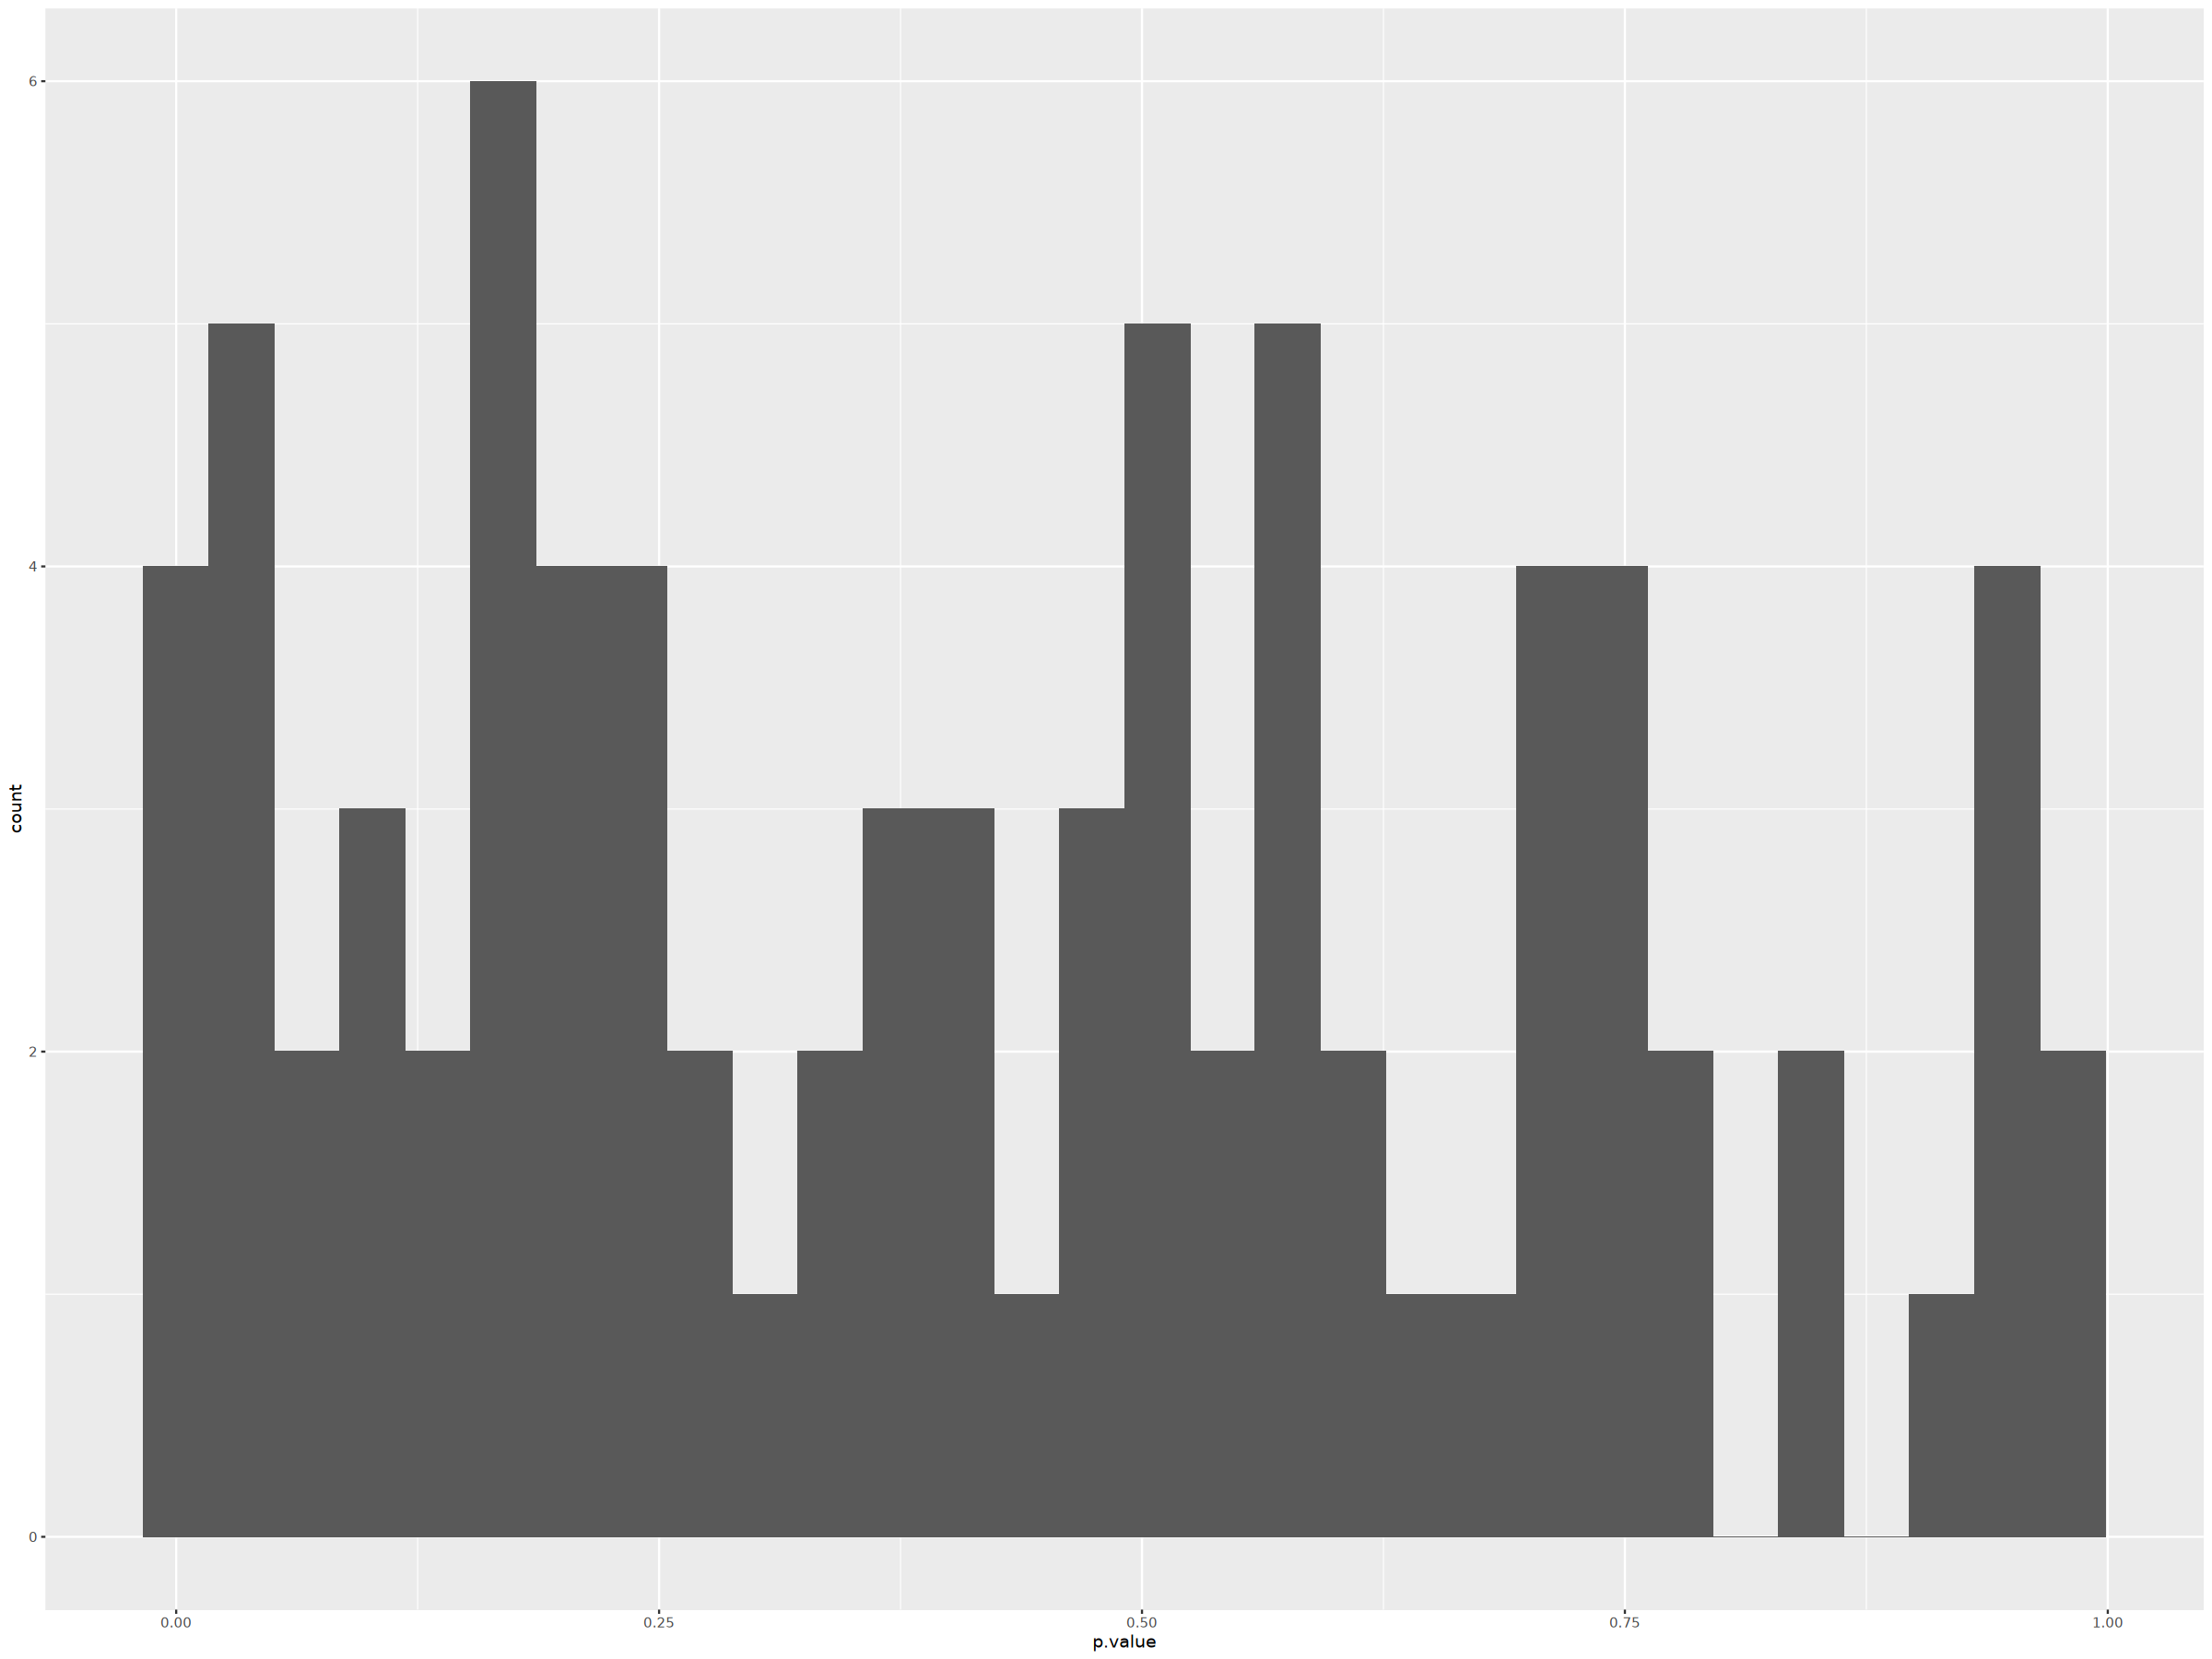

In [132]:
freq_stats_lme %>% ungroup() %>% filter(term=='days_to_conversion')%>%
    ggplot(aes(p.value)) + geom_histogram()

In [133]:
# check frequency changes
freq_stats_lme %>%
    filter(term=='days_to_conversion') %>% 
    arrange(p.value)%>%head(10)

AIFI_L3_new,effect,group,term,estimate,std.error,statistic,df,p.value,celltype
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ASDC_uk1_B,fixed,NA,days_to_conversion,-0.0009195660,0.0003201099,-2.872657,46.00000,0.006138637,ASDC_uk1_B
ISG+ cDC2,fixed,NA,days_to_conversion,-0.0008794109,0.0003189739,-2.757000,42.68049,0.008548418,ISG+ cDC2
SOX4+ naive CD4 T cell,fixed,NA,days_to_conversion,-0.0006232588,0.0002460128,-2.533440,37.18069,0.015640822,SOX4+ naive CD4 T cell
DN T cell,fixed,NA,days_to_conversion,0.0004714277,0.0001865621,2.526921,38.01167,0.015788439,DN T cell
Intermediate monocyte,fixed,NA,days_to_conversion,-0.0010331483,0.0004630083,-2.231382,46.00000,0.030570438,Intermediate monocyte
Plasma cell,fixed,NA,days_to_conversion,0.0007494933,0.0003448256,2.173543,44.75029,0.035071132,Plasma cell
KLRF1+ GZMB+ CD27- EM CD8 T cell,fixed,NA,days_to_conversion,0.0005226747,0.0002395604,2.181808,36.46769,0.035646374,KLRF1+ GZMB+ CD27- EM CD8 T cell
GZMK+ CD27+ EM CD8 T cell_uk1_gdt,fixed,NA,days_to_conversion,-0.0005515247,0.0002537605,-2.173406,39.03574,0.035879220,GZMK+ CD27+ EM CD8 T cell_uk1_gdt
GZMB- CD27- EM CD4 T cell,fixed,NA,days_to_conversion,0.0004426204,0.0002111563,2.096175,43.43788,0.041927326,GZMB- CD27- EM CD4 T cell


In [134]:
aim3_l3_freq%>%colnames()

[1] "AIFI_L3_new"           "sample.sampleKitGuid"  "counts"               
 [4] "pseudo_counts"         "pseudo_total_counts"   "subject.subjectGuid"  
 [7] "subject.biologicalSex" "age_conv"              "bmi_conv"             
[10] "CMV_Status_Subj"       "status"                "file.batchID"         
[13] "Status_Xsec"           "Status_Long"           "days_to_conversion"   
[16] "frequency"             "pseudo_frequency"      "pseudo_clr"

In [135]:
# filter out frequency changes related in time to conversion
freq_stats_lme_sig <- freq_stats_lme %>% ungroup() %>% 
    filter(term=='days_to_conversion')%>%
    rstatix::adjust_pvalue(method = "BH") %>% arrange( p.value)
# save the model results
freq_stats_lme_sig%>%
    write_csv(file.path(output_path, paste0(proj_name,'AIM3_DA_mixed_model_female_results.csv')))


In [136]:
freq_stats_lme_sig%>%head()

AIFI_L3_new,effect,group,term,estimate,std.error,statistic,df,p.value,celltype,p.value.adj
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
ASDC_uk1_B,fixed,NA,days_to_conversion,-0.0009195660,0.0003201099,-2.872657,46.00000,0.006138637,ASDC_uk1_B,0.3157688
ISG+ cDC2,fixed,NA,days_to_conversion,-0.0008794109,0.0003189739,-2.757000,42.68049,0.008548418,ISG+ cDC2,0.3157688
SOX4+ naive CD4 T cell,fixed,NA,days_to_conversion,-0.0006232588,0.0002460128,-2.533440,37.18069,0.015640822,SOX4+ naive CD4 T cell,0.3157688
DN T cell,fixed,NA,days_to_conversion,0.0004714277,0.0001865621,2.526921,38.01167,0.015788439,DN T cell,0.3157688
Intermediate monocyte,fixed,NA,days_to_conversion,-0.0010331483,0.0004630083,-2.231382,46.00000,0.030570438,Intermediate monocyte,0.3587922
Plasma cell,fixed,NA,days_to_conversion,0.0007494933,0.0003448256,2.173543,44.75029,0.035071132,Plasma cell,0.3587922


## run paired analysis for AIM3

In [6]:
# save aim3 frequency table
aim3_l3_freq <- read_csv(file.path(output_path, paste0(proj_name, 'AIM3_frequency_table.csv')))

Rows: 5655 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (9): AIFI_L3_new, sample.sampleKitGuid, subject.subjectGuid, subject.bio...
dbl (9): counts, pseudo_counts, pseudo_total_counts, age_conv, bmi_conv, day...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
# load metadata for the paired analysis
pair_sample<-read_csv(file.path('/home/jupyter/data/ra_longitudinal/output_results',
                                  'AIM3_paired_pre_post_conversion_samples.csv'))

Rows: 22 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): subject.subjectGuid, sample.sampleKitGuid, file.batchID, sample.di...
dbl  (2): days_to_conversion, pair_number
date (1): sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
# filter the freq table for the samples in pair comparison
pair_l3_freq <- aim3_l3_freq%>%filter(sample.sampleKitGuid %in% pair_sample$sample.sampleKitGuid)%>%
    select(-status)%>%
    left_join(select(pair_sample, c(sample.sampleKitGuid, status)), by='sample.sampleKitGuid')%>%
    mutate(status=factor(status, levels = c('pre_conv', 'conversion')))

In [16]:
pair_l3_freq%>%distinct(status)

status
<fct>
pre_conv
conversion


In [26]:
pair_l3_freq%>%colnames()

[1] "AIFI_L3_new"           "sample.sampleKitGuid"  "counts"               
 [4] "pseudo_counts"         "pseudo_total_counts"   "subject.subjectGuid"  
 [7] "subject.biologicalSex" "age_conv"              "bmi_conv"             
[10] "CMV_Status_Subj"       "file.batchID"          "Status_Xsec"          
[13] "Status_Long"           "days_to_conversion"    "frequency"            
[16] "pseudo_frequency"      "pseudo_clr"            "status"

In [34]:
# run statistic test
freq_stats_wilcox <- pair_l3_freq %>% 
    group_by(AIFI_L3_new) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(frequency ~ status, paired = TRUE) %>%
    rstatix::adjust_pvalue(method = "BH") %>%
    rstatix::add_significance("p.adj") 
freq_stats_wilcox%>%arrange(p)%>%head(10)

AIFI_L3_new,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Core CD14 monocyte,frequency,pre_conv,conversion,11,11,56,0.0420,0.731,ns
SOX4+ Vd1 gdT,frequency,pre_conv,conversion,11,11,9,0.0665,0.731,ns
ISG+ naive B cell,frequency,pre_conv,conversion,11,11,12,0.0674,0.731,ns
ISG+ naive CD4 T cell,frequency,pre_conv,conversion,11,11,12,0.0674,0.731,ns
Platelet,frequency,pre_conv,conversion,11,11,54,0.0674,0.731,ns
CD27- effector B cell,frequency,pre_conv,conversion,11,11,53,0.0830,0.731,ns
Core naive CD4 T cell,frequency,pre_conv,conversion,11,11,13,0.0830,0.731,ns
Type 2 polarized memory B cell,frequency,pre_conv,conversion,11,11,53,0.0830,0.731,ns
ASDC_uk1_B,frequency,pre_conv,conversion,11,11,45,0.0831,0.731,ns


In [35]:
freq_stats_wilcox %>% filter(AIFI_L3_new=='Core CD16 monocyte')

AIFI_L3_new,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Core CD16 monocyte,frequency,pre_conv,conversion,11,11,35,0.898,0.97395,ns


In [36]:
# check the result
cd16mon_pair = pair_l3_freq %>% filter(AIFI_L3_new=='Core CD16 monocyte') %>% 
    pivot_wider(id_cols = 'subject.subjectGuid', names_from = 'status', values_from = 'frequency')
wilcox.test(cd16mon_pair$pre_conv, cd16mon_pair$conversion, paired = TRUE)


	Wilcoxon signed rank exact test

data:  cd16mon_pair$pre_conv and cd16mon_pair$conversion
V = 35, p-value = 0.8984
alternative hypothesis: true location shift is not equal to 0


## run paired analysis for RA conversion and last pre-conversion timepoint

In [5]:
# subset the data to pair analysis pre and post conversion
pair_kit = c('KT00493','KT02135','KT04474','KT04108',
             'KT04105','KT04462','KT00500','KT02844','KT03930',
             'KT04085','KT02164','KT02963','KT02854','KT02975',
             'KT03939','KT04924','KT00468','KT02856','KT00103','KT00109','KT00105','KT00790')
pair_kit%>%length()

[1] 22

In [6]:
# subset aim3 paired data
paired_meta <- read_csv(file.path('/home/jupyter/data/ra_longitudinal/output_results',
                          'AIM3_paired_pre_post_conversion_samples.csv'))
paired_meta

Rows: 22 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): subject.subjectGuid, sample.sampleKitGuid, file.batchID, sample.di...
dbl  (2): days_to_conversion, pair_number
date (1): sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


subject.subjectGuid,sample.drawDate,sample.sampleKitGuid,file.batchID,sample.diseaseStatesRecordedAtVisit,Status_Long,days_to_conversion,pair_number,status
<chr>,<date>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
CU1003,2021-02-01,KT00493,B176,Rheumatoid arthritis,pre,-127,2,pre_conv
CU1003,2021-06-01,KT02135,B087,Rheumatoid arthritis,conversion,0,2,conversion
CU1010,2022-09-01,KT04474,B178,Rheumatoid arthritis,pre,-102,2,pre_conv
CU1010,2023-01-01,KT04108,B164,CCP3+ At Risk for RA,conversion,0,2,conversion
CU1021,2022-08-01,KT04105,B140,Rheumatoid arthritis,pre,-107,2,pre_conv
CU1021,2022-11-01,KT04462,B158,Rheumatoid arthritis,conversion,0,2,conversion
CU1029,2021-03-01,KT00500,B176,Rheumatoid arthritis,pre,-230,2,pre_conv
CU1029,2021-10-01,KT02844,B103,Rheumatoid arthritis,conversion,0,2,conversion
CU1037,2022-08-01,KT03930,B164,Rheumatoid arthritis,pre,-91,2,pre_conv


In [ ]:
# subset the frequency table to just the paired analysis
paied_l3_freq <- aim3_l3_freq%>% filter(sample.sampleKitGuid%in%paired_meta$sample.sampleKitGuid)%>%
    select(-status)%>%
    left_join(select(paired_meta, c(sample.sampleKitGuid, status)), by='sample.sampleKitGuid')%>%
    mutate(status=factor(status, levels = c('pre_conv','conversion')))
paied_l3_freq%>%head()

In [ ]:
paied_l3_freq%>%filter(AIFI_L3_new== 'KLRB1+ memory CD4 Treg')%>%colnames()

In [ ]:
 # run wilcox test for frequency pretreatment vs healthy 
freq_stats_wilcox_pair <- paied_l3_freq %>%
    group_by(AIFI_L3_new) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(data =., pseudo_clr ~ status, paired = TRUE) %>%
      rstatix::adjust_pvalue(method = "BH") %>%
      rstatix::add_significance("p.adj") 
freq_stats_wilcox_pair_sig = freq_stats_wilcox_pair %>% arrange(p)%>%filter(p<0.05)
freq_stats_wilcox_pair_sig

In [ ]:
p1<- paied_l3_freq %>% filter(AIFI_L3_new%in%freq_stats_wilcox_pair_sig$AIFI_L3_new)%>%
    ggplot(aes(x=status, y=frequency, color=subject.subjectGuid, group=subject.subjectGuid))+
   geom_point() + geom_line() + facet_wrap(vars(AIFI_L3_new), scales = 'free_y') + 
    ylab('Frequency of live')
p1
# ggsave(file.path(fig_path, paste0(proj_name, '_mono_frequency_clr.png')), width=8, height=4)

### run pair analysis for DA for monocytes

In [5]:
# load frequency of monocytes
mono_freq <- read_csv(
    '/home/jupyter/data/ra_longitudinal/output_results/cd16mono/RA_lg_converters_scRNA_mono_paired_mono_AIFI_L3_new_frequency.csv'
)%>%
    mutate(cell_type=factor(cell_type), 
          Sex=subject.biologicalSex)%>%
    mutate(status=factor(recode(status, 'pre_conv'="Pre-clinical RA", 'conversion'='Clinical RA'), 
                         levels = c("Pre-clinical RA",'Clinical RA')))
mono_freq %>%head()

New names:
• `` -> `...1`
Rows: 154 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): sample.sampleKitGuid, cell_type, subject.subjectGuid, subject.biolo...
dbl (4): ...1, counts, total_mono_counts, mono_frequency

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex
<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>
0,KT00103,C1Q+ CD16 monocyte,10,SD1003,Female,Pre-clinical RA,B046,815,0.012269939,Female
1,KT00103,Core CD14 monocyte,680,SD1003,Female,Pre-clinical RA,B046,815,0.834355828,Female
2,KT00103,Core CD16 monocyte,54,SD1003,Female,Pre-clinical RA,B046,815,0.066257669,Female
3,KT00103,IL1B+ CD14 monocyte,3,SD1003,Female,Pre-clinical RA,B046,815,0.003680982,Female
4,KT00103,ISG+ CD14 monocyte,35,SD1003,Female,Pre-clinical RA,B046,815,0.042944785,Female
5,KT00103,ISG+ CD16 monocyte,4,SD1003,Female,Pre-clinical RA,B046,815,0.004907975,Female


In [7]:
# perform clr transformation
mono_freq_clr <- FreqClrTran(mono_freq, freq_col='mono_frequency',
                                   celltype_col='cell_type', clr_name='clr',
                          sample_col='sample.sampleKitGuid')

Loading required package: compositions

Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:Matrix’:

    norm


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




In [8]:
mono_freq_clr%>%filter(counts==0)

...1,sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex,clr
<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>


In [9]:
mono_freq_clr%>%group_by(cell_type, subject.subjectGuid)%>%tally()%>%filter(n!=2)

cell_type,subject.subjectGuid,n
<chr>,<chr>,<int>


In [10]:
mono_freq_clr%>%distinct(status)

status
<fct>
Pre-clinical RA
Clinical RA


In [23]:
 # run wilcox test for frequency pretreatment vs healthy 
freq_stats_wilcox_pair <- mono_freq_clr %>% #filter(cell_type%in%c('IL1B+ CD14 monocyte'))%>%
    group_by(cell_type) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(data =., mono_frequency ~ status, paired = TRUE) %>%
      rstatix::adjust_pvalue(method = "BH") %>% 
      rstatix::add_significance("p.adj") %>%arrange(p)
freq_stats_wilcox_pair

cell_type,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
IL1B+ CD14 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,7,0.0186,0.1302000,ns
Core CD14 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,56,0.0420,0.1470000,ns
Core CD16 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,15,0.1230,0.2870000,ns
ISG+ CD16 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,18,0.2060,0.3360000,ns
C1Q+ CD16 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,19,0.2400,0.3360000,ns
Intermediate monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,22,0.3650,0.4258333,ns
ISG+ CD14 monocyte,mono_frequency,Pre-clinical RA,Clinical RA,11,11,29,0.7650,0.7650000,ns


In [24]:
 # run wilcox test for frequency pretreatment vs healthy 
freq_stats_wilcox_pair <- mono_freq_clr %>% #filter(cell_type%in%c('IL1B+ CD14 monocyte'))%>%
    group_by(cell_type) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(data =., clr ~ status, paired = TRUE) %>%
      rstatix::adjust_pvalue(method = "BH") %>% 
      rstatix::add_significance("p.adj") %>%arrange(p)
freq_stats_wilcox_pair

cell_type,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Core CD14 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,58,0.0244,0.1708,ns
IL1B+ CD14 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,17,0.1750,0.5600,ns
ISG+ CD16 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,20,0.2780,0.5600,ns
ISG+ CD14 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,45,0.3200,0.5600,ns
Intermediate monocyte,clr,Pre-clinical RA,Clinical RA,11,11,40,0.5770,0.8078,ns
C1Q+ CD16 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,29,0.7650,0.8925,ns
Core CD16 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,34,0.9660,0.9660,ns


In [12]:
 # run wilcox test for frequency pretreatment vs healthy 
freq_stats_wilcox_pair <- mono_freq_clr %>% filter(cell_type%in%c('IL1B+ CD14 monocyte'))%>%
    group_by(cell_type) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(data =., clr ~ status, paired = TRUE) %>%
      rstatix::adjust_pvalue(method = "BH") %>% 
      rstatix::add_significance("p.adj") 
freq_stats_wilcox_pair

cell_type,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
IL1B+ CD14 monocyte,clr,Pre-clinical RA,Clinical RA,11,11,17,0.175,0.175,ns


### plot Fig2I

In [82]:
# define the function
pairViolinPlot <- function(freq, celltype_plot, x_axis = 'status', y_axis = 'mono_frequency',
                           ylab="Freuqnecy in monocytes", group_colors = ari_colors){
    freq_fl <- freq %>%
            filter(cell_type == celltype_plot)
    pair_nums = freq_fl %>% group_by(subject.subjectGuid)%>%tally()
    pair_subs = pair_nums %>% filter(n>=2) %>% pull(subject.subjectGuid) %>% unique()
    p1 <- freq_fl %>% filter(subject.subjectGuid%in%pair_subs) %>%
            ggplot(aes(x = .data[[x_axis]], y = .data[[y_axis]])) +
            geom_violin(aes(color = status)) +
            geom_point(aes(group = subject.subjectGuid, shape=Sex), color='grey', size=1.5) +
            geom_line(aes(group = subject.subjectGuid), color='grey') +
            labs(title = celltype_plot, x = "", y = ylab) +
            scale_color_manual(values = group_colors[2:3]) +
            theme_classic() +
            theme(
                text = element_text(size = 10, face = "bold"),
                axis.title = element_text(size = 10, face = "bold"),
                axis.text = element_text(size = 10, face = "bold"),
                plot.title = element_text(size = 10, face = "bold"),
                axis.text.x = element_text(angle = 45, vjust = 1, hjust=1),
                legend.position = "none"
            ) +
           # scale_shape_manual(values = c(16, 2)) +
            guides(color = 'none', fill = 'none')
    
    ggsave(file.path(fig_path, paste0(proj_name, celltype_plot, '_',  y_axis,
                                          ".pdf")), 
           width = 2.66*2, height = 4.35*2, units='cm', dpi=300)
    return(p1)
}

In [19]:
mono_freq_clr%>%distinct(cell_type)

cell_type
<chr>
C1Q+ CD16 monocyte
Core CD14 monocyte
Core CD16 monocyte
IL1B+ CD14 monocyte
ISG+ CD14 monocyte
ISG+ CD16 monocyte
Intermediate monocyte


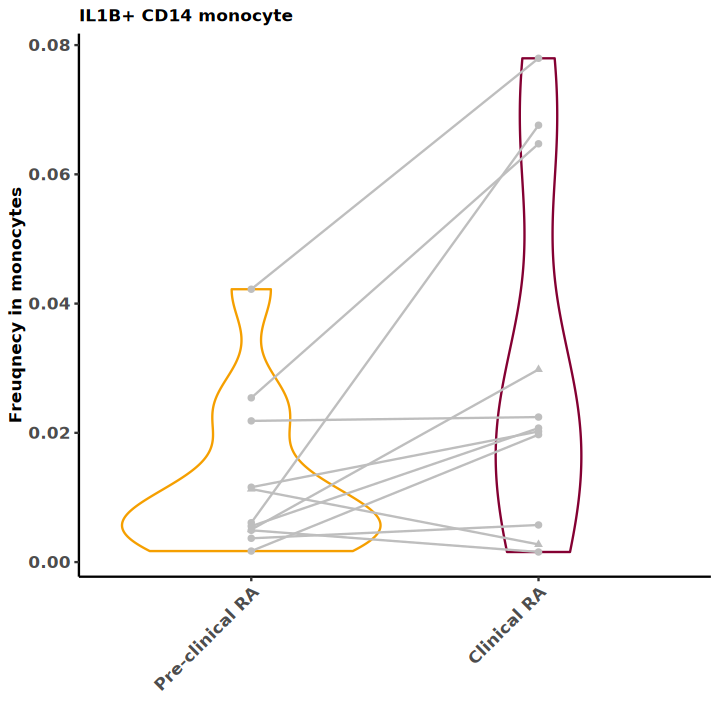

In [78]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'IL1B+ CD14 monocyte',
               x_axis = 'status', y_axis = 'mono_frequency',
               group_colors = ari_colors)

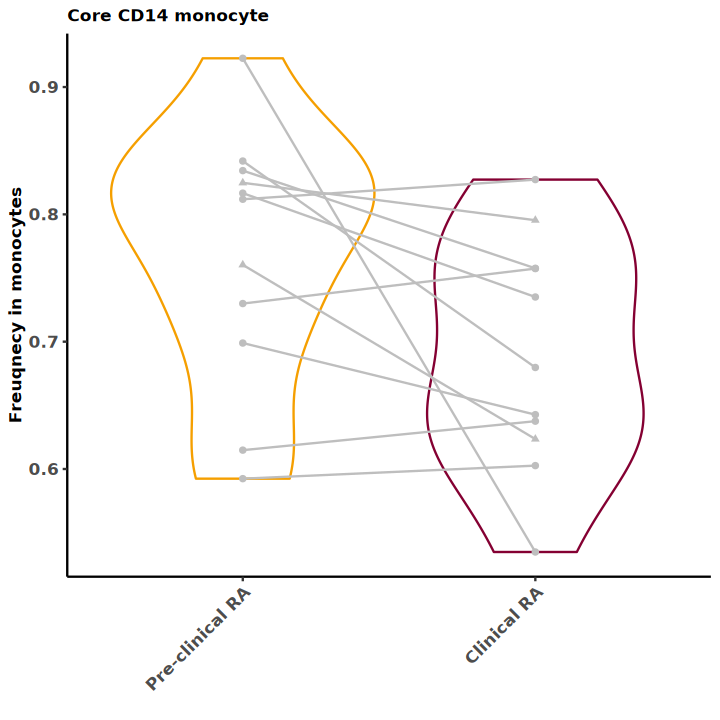

In [70]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'Core CD14 monocyte',
               x_axis = 'status', y_axis = 'mono_frequency',
               group_colors = ari_colors)

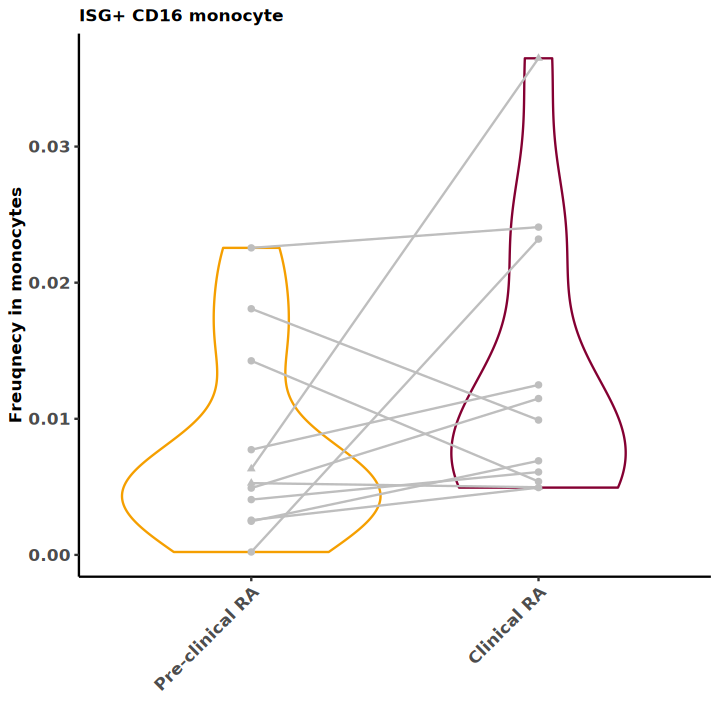

In [25]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'ISG+ CD16 monocyte',
               x_axis = 'status', y_axis = 'mono_frequency',
               group_colors = ari_colors)

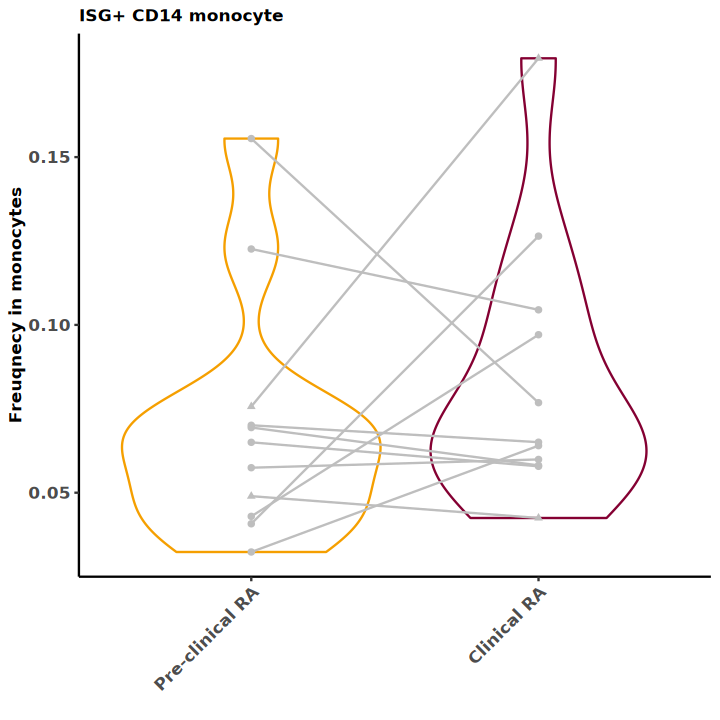

In [20]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'ISG+ CD14 monocyte',
               x_axis = 'status', y_axis = 'mono_frequency',
               group_colors = ari_colors)

In [ ]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'ISG+ CD14 monocyte',
               x_axis = 'status', y_axis = 'mono_frequency',
               group_colors = ari_colors)

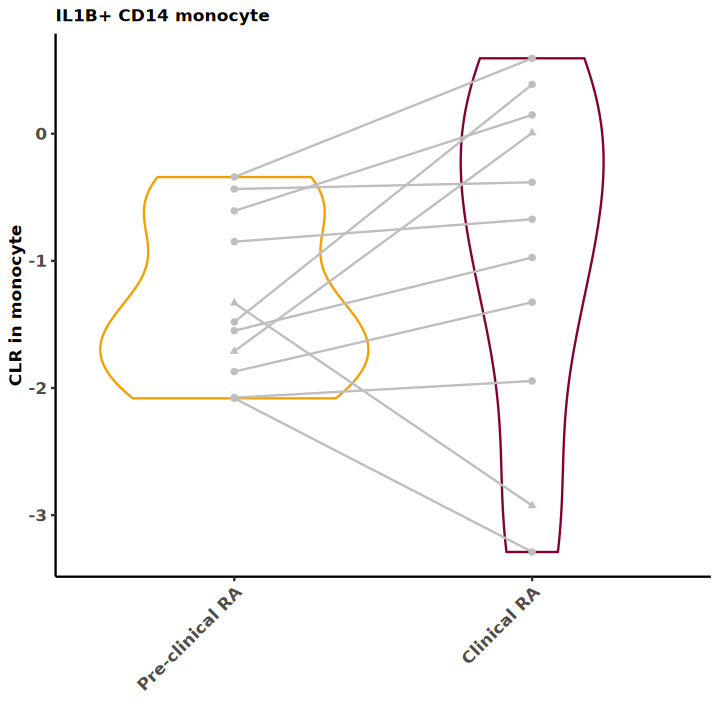

In [18]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'IL1B+ CD14 monocyte',
               x_axis = 'status', y_axis = 'clr', ylab='CLR in monocyte',
               group_colors = ari_colors)

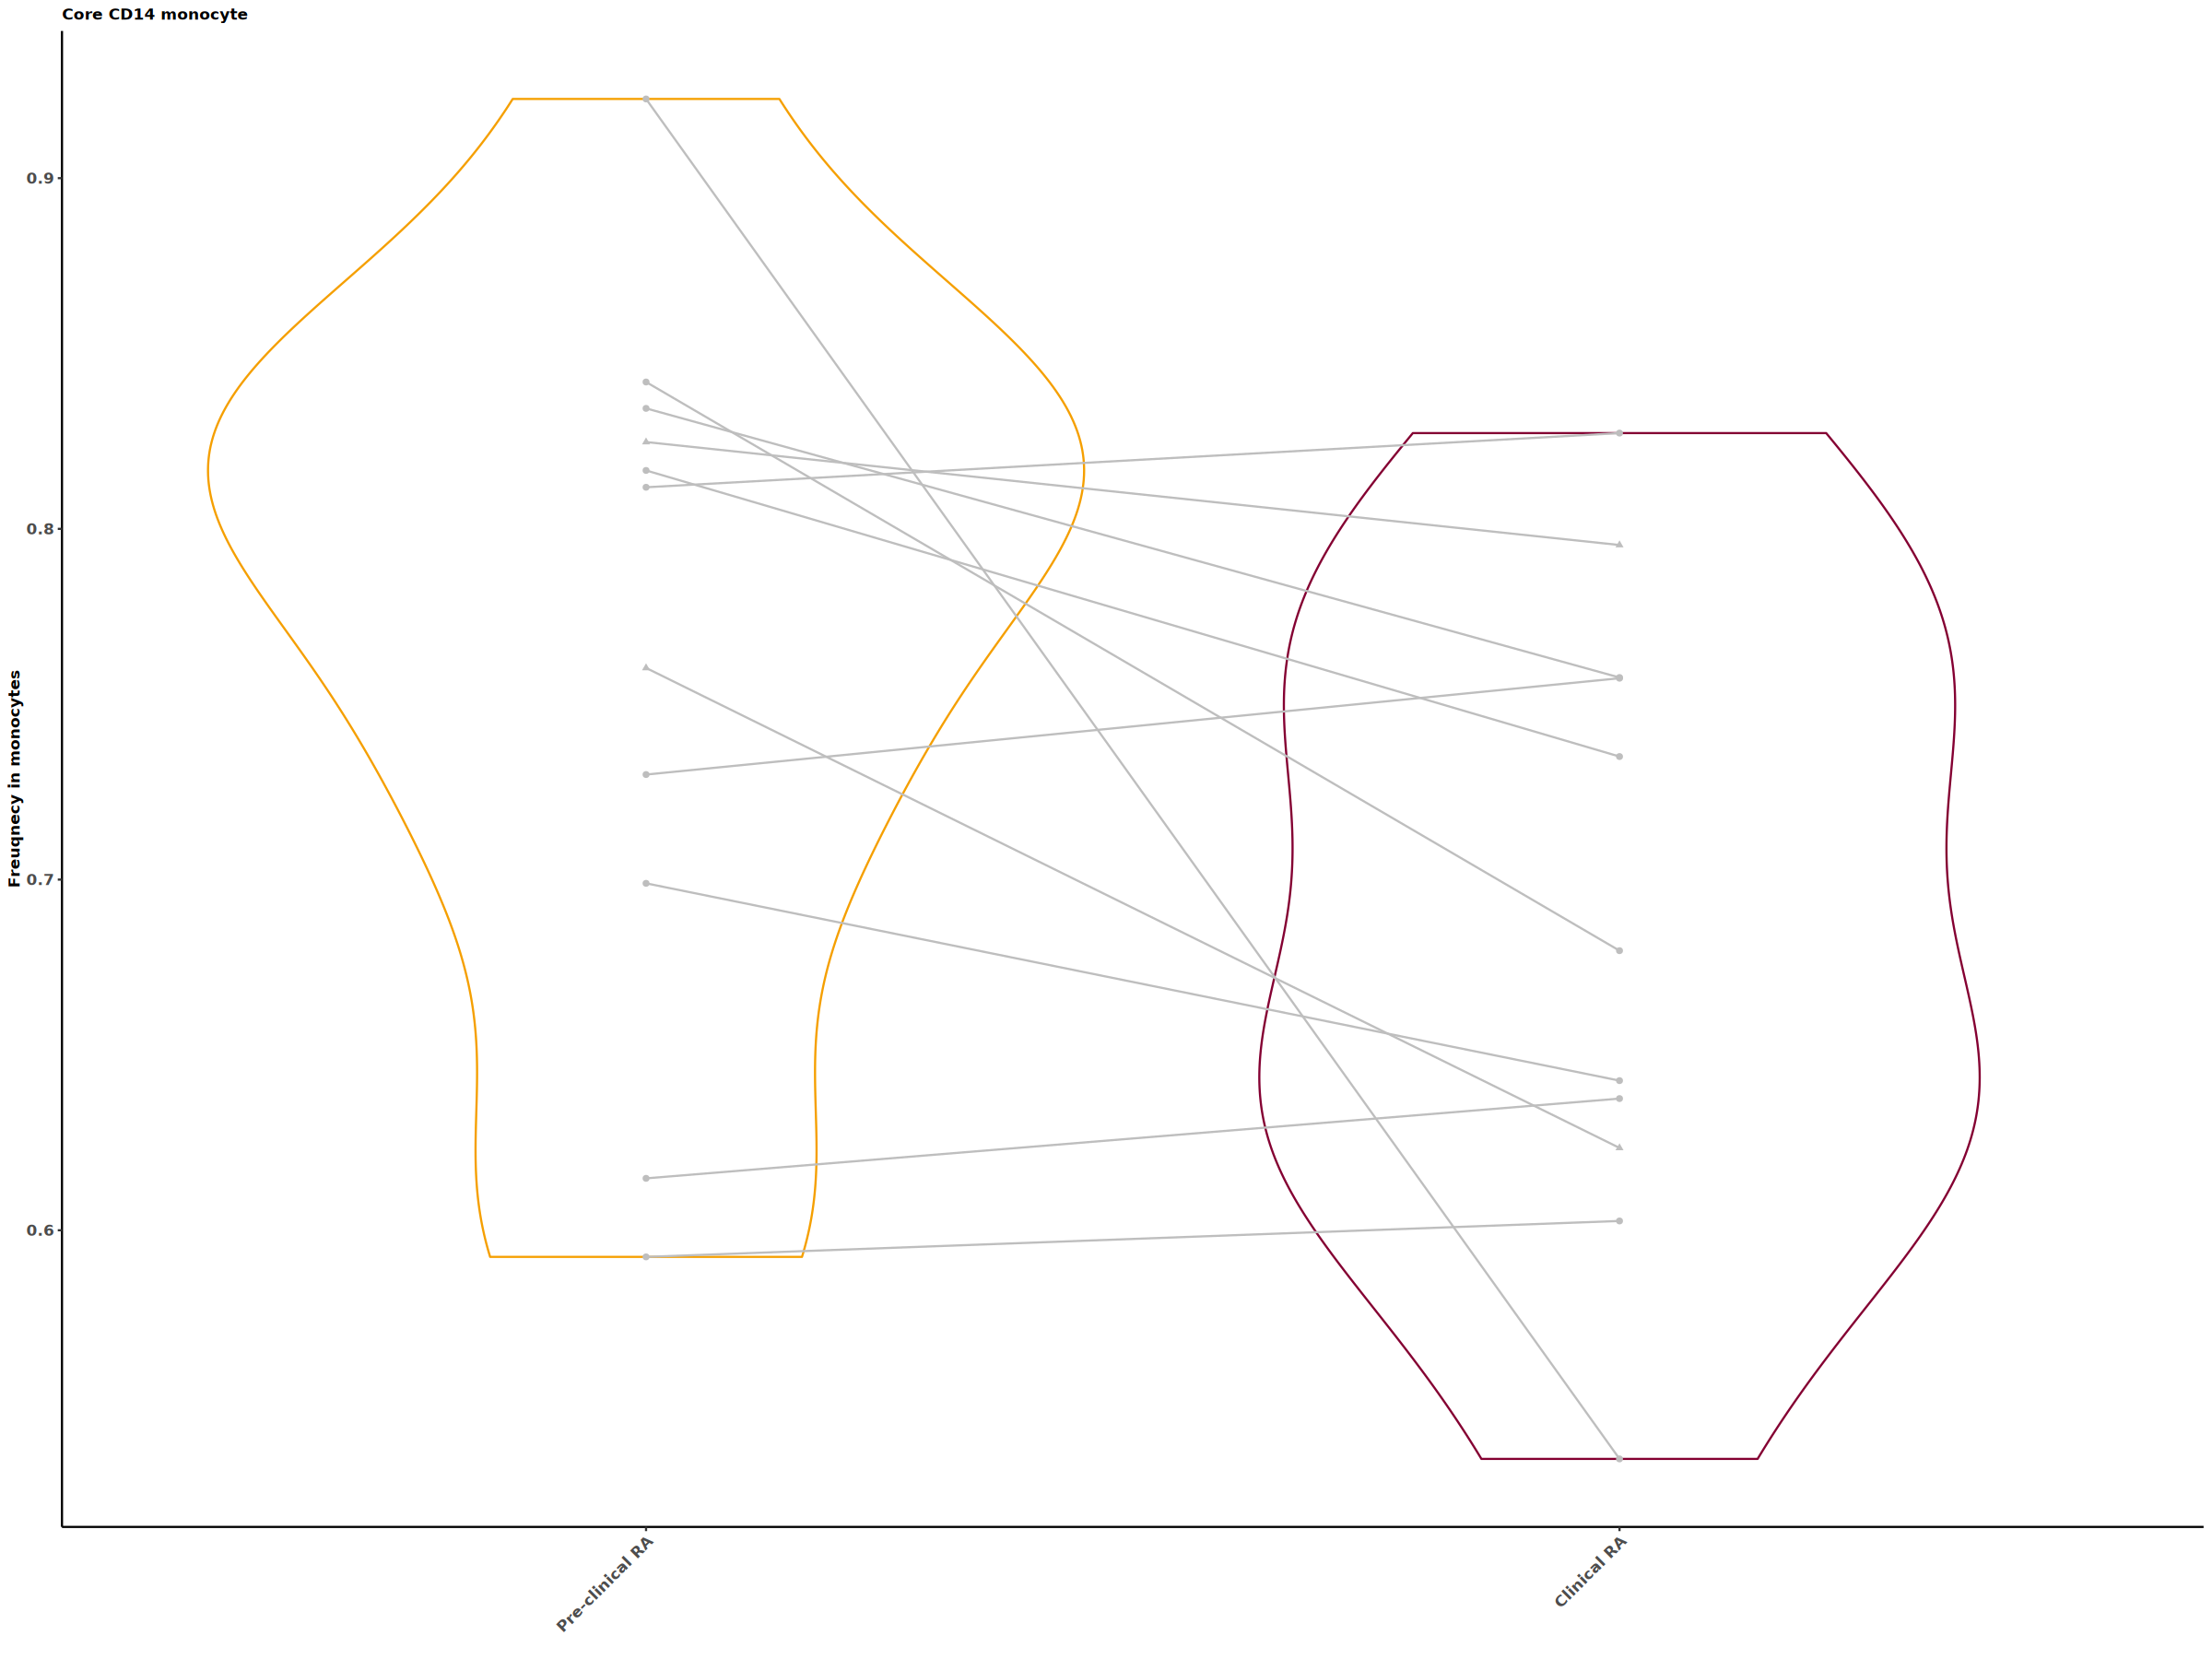

In [22]:
pairViolinPlot(mono_freq_clr, celltype_plot = 'Core CD14 monocyte', group_colors = ari_colors)

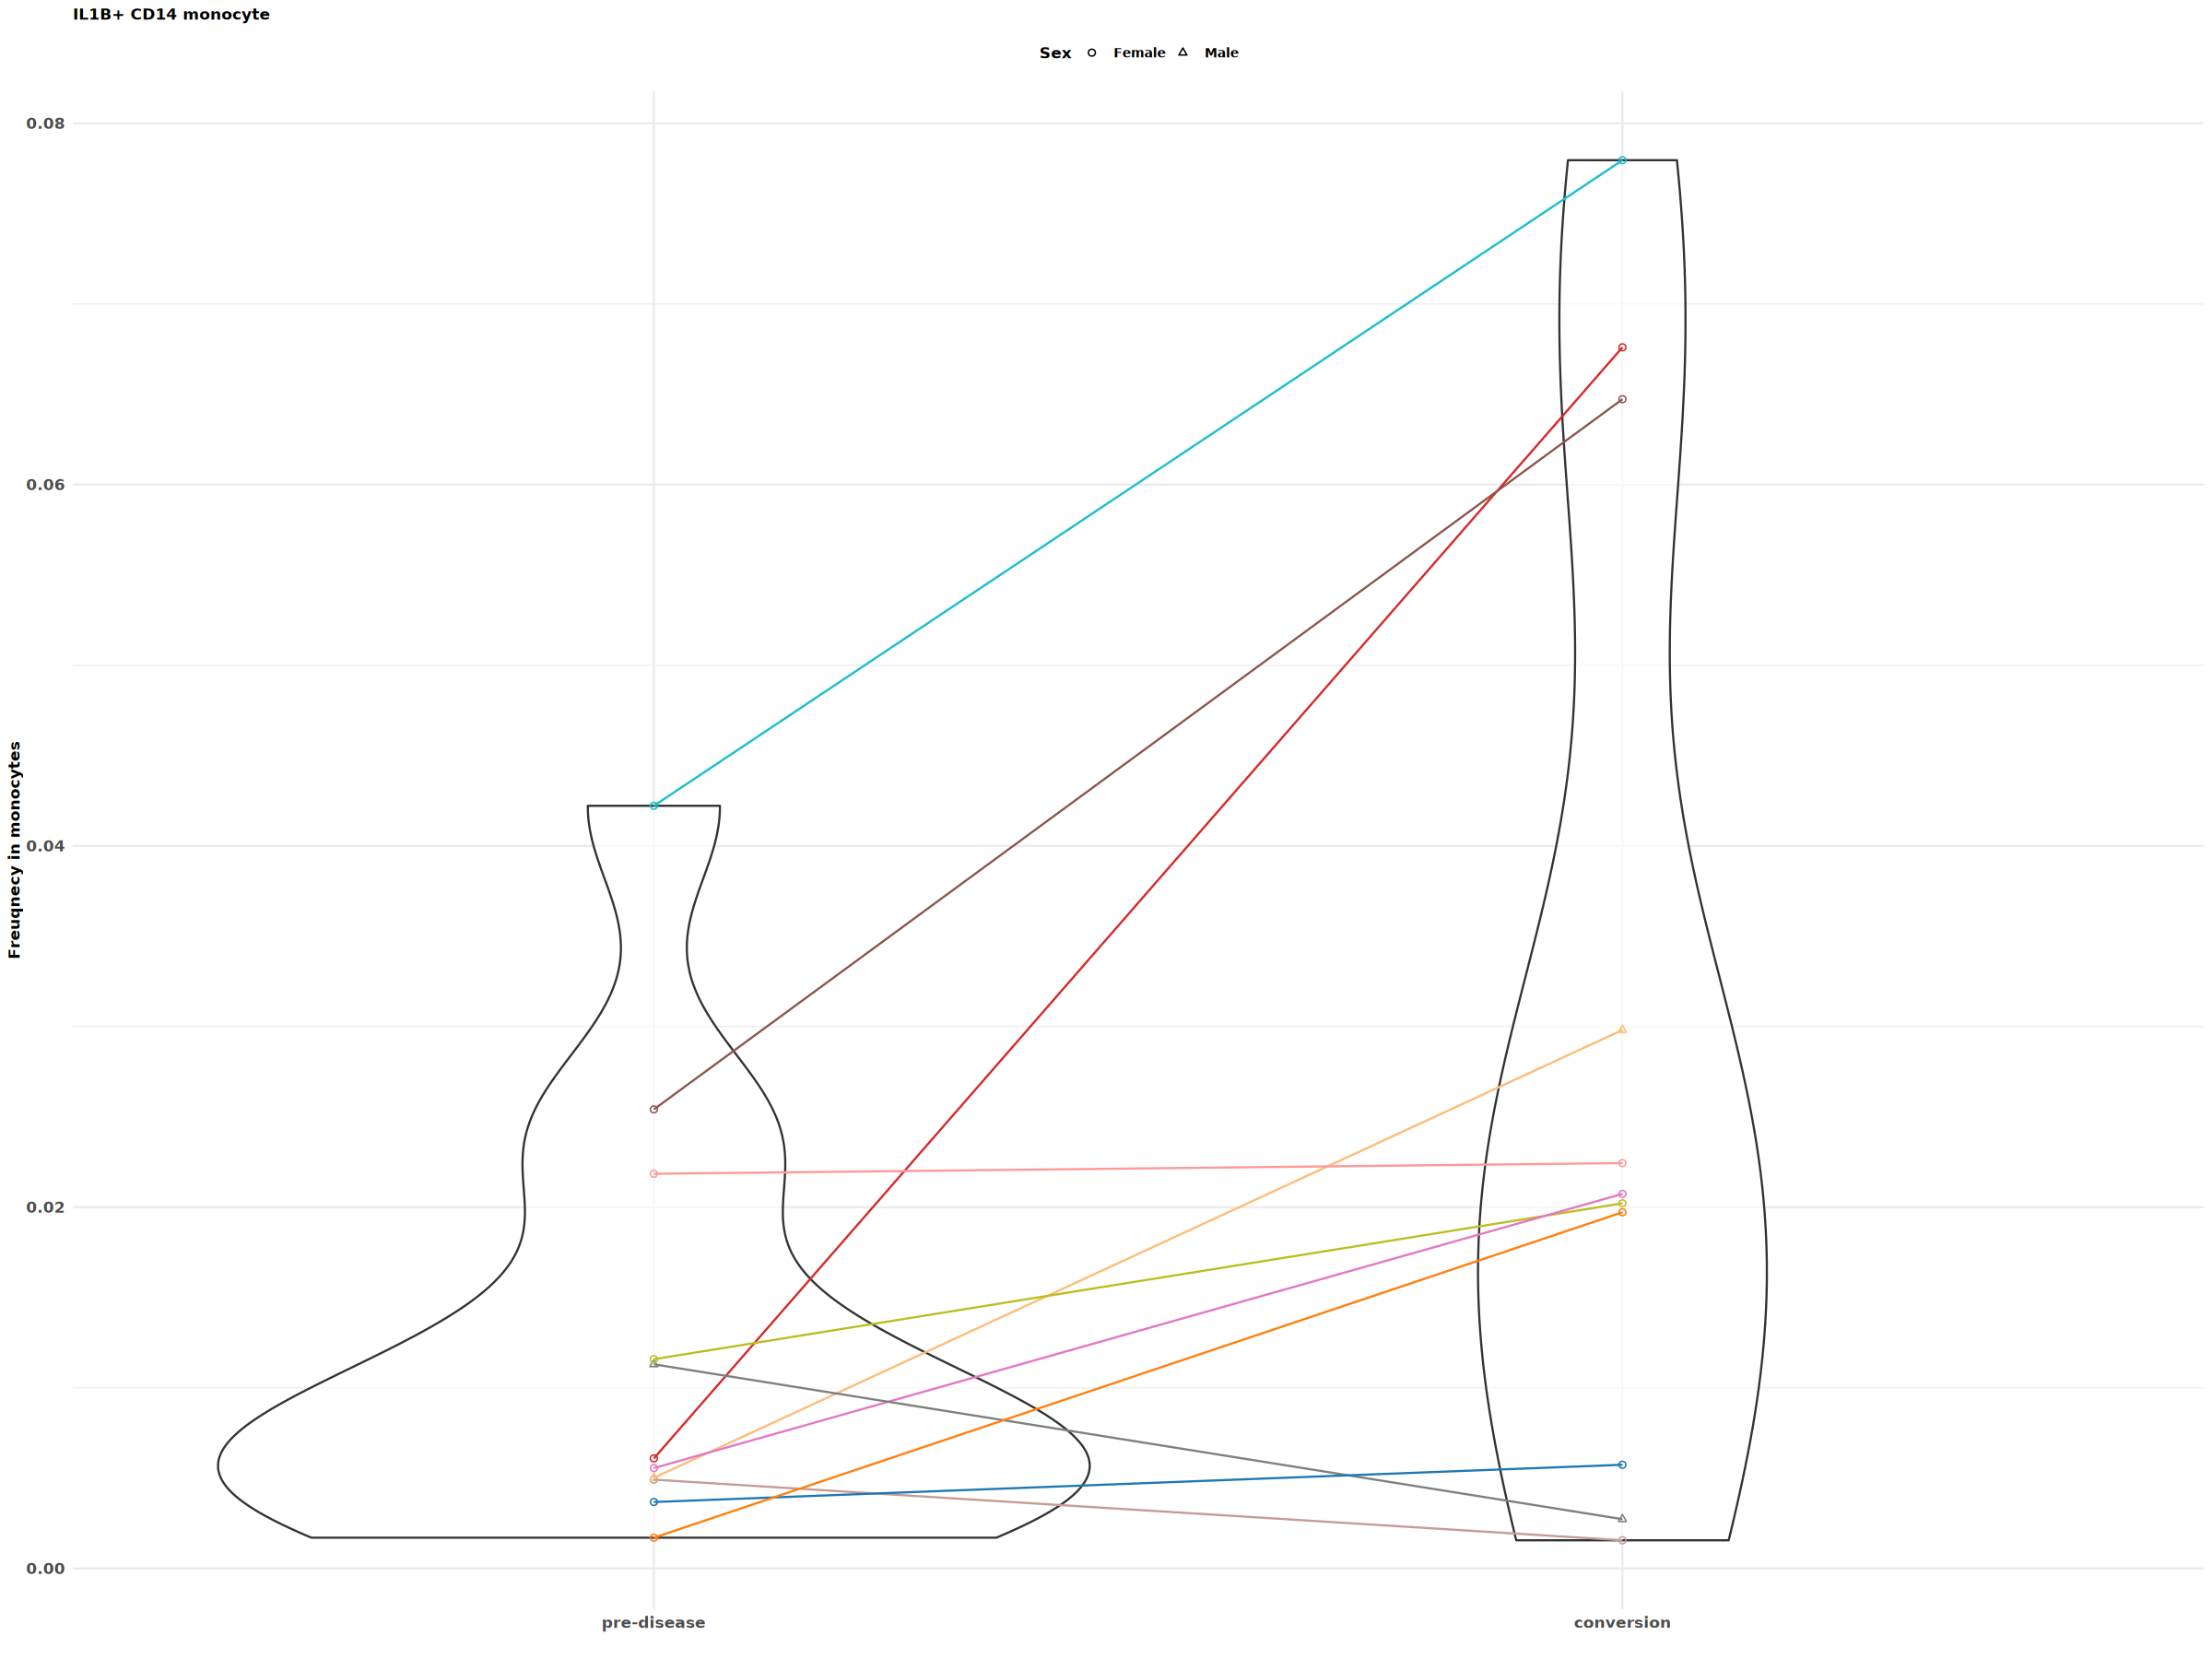

In [50]:
p2 <- mono_freq_clr %>% filter(cell_type=='IL1B+ CD14 monocyte') %>% 
        ggplot(aes(x = status, y = mono_frequency)) +
        geom_violin(aes(), alpha = 0.6) +
        geom_point(aes(group = subject.subjectGuid, color = subject.subjectGuid, shape = Sex)) +
        geom_line(aes(group = subject.subjectGuid, color = subject.subjectGuid)) +
        labs(title = "IL1B+ CD14 monocyte", x = "", y = "Freuqnecy in monocytes") +
        scale_color_subj() +
        theme_minimal() +
        theme(
            text = element_text(size = 10, face = "bold"),
            axis.title = element_text(size = 10, face = "bold"),
            axis.text = element_text(size = 10, face = "bold"),
            plot.title = element_text(size = 10, face = "bold"),
            legend.position = "top"
        ) +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = 'none', fill = 'none')
p2
ggsave(file.path(fig_path, paste0(proj_name, "paired_monocyte_IL1B_cd14mon_freq.pdf")),
       width = 2.66*2, height = 4.35*2, units='cm', dpi=300)

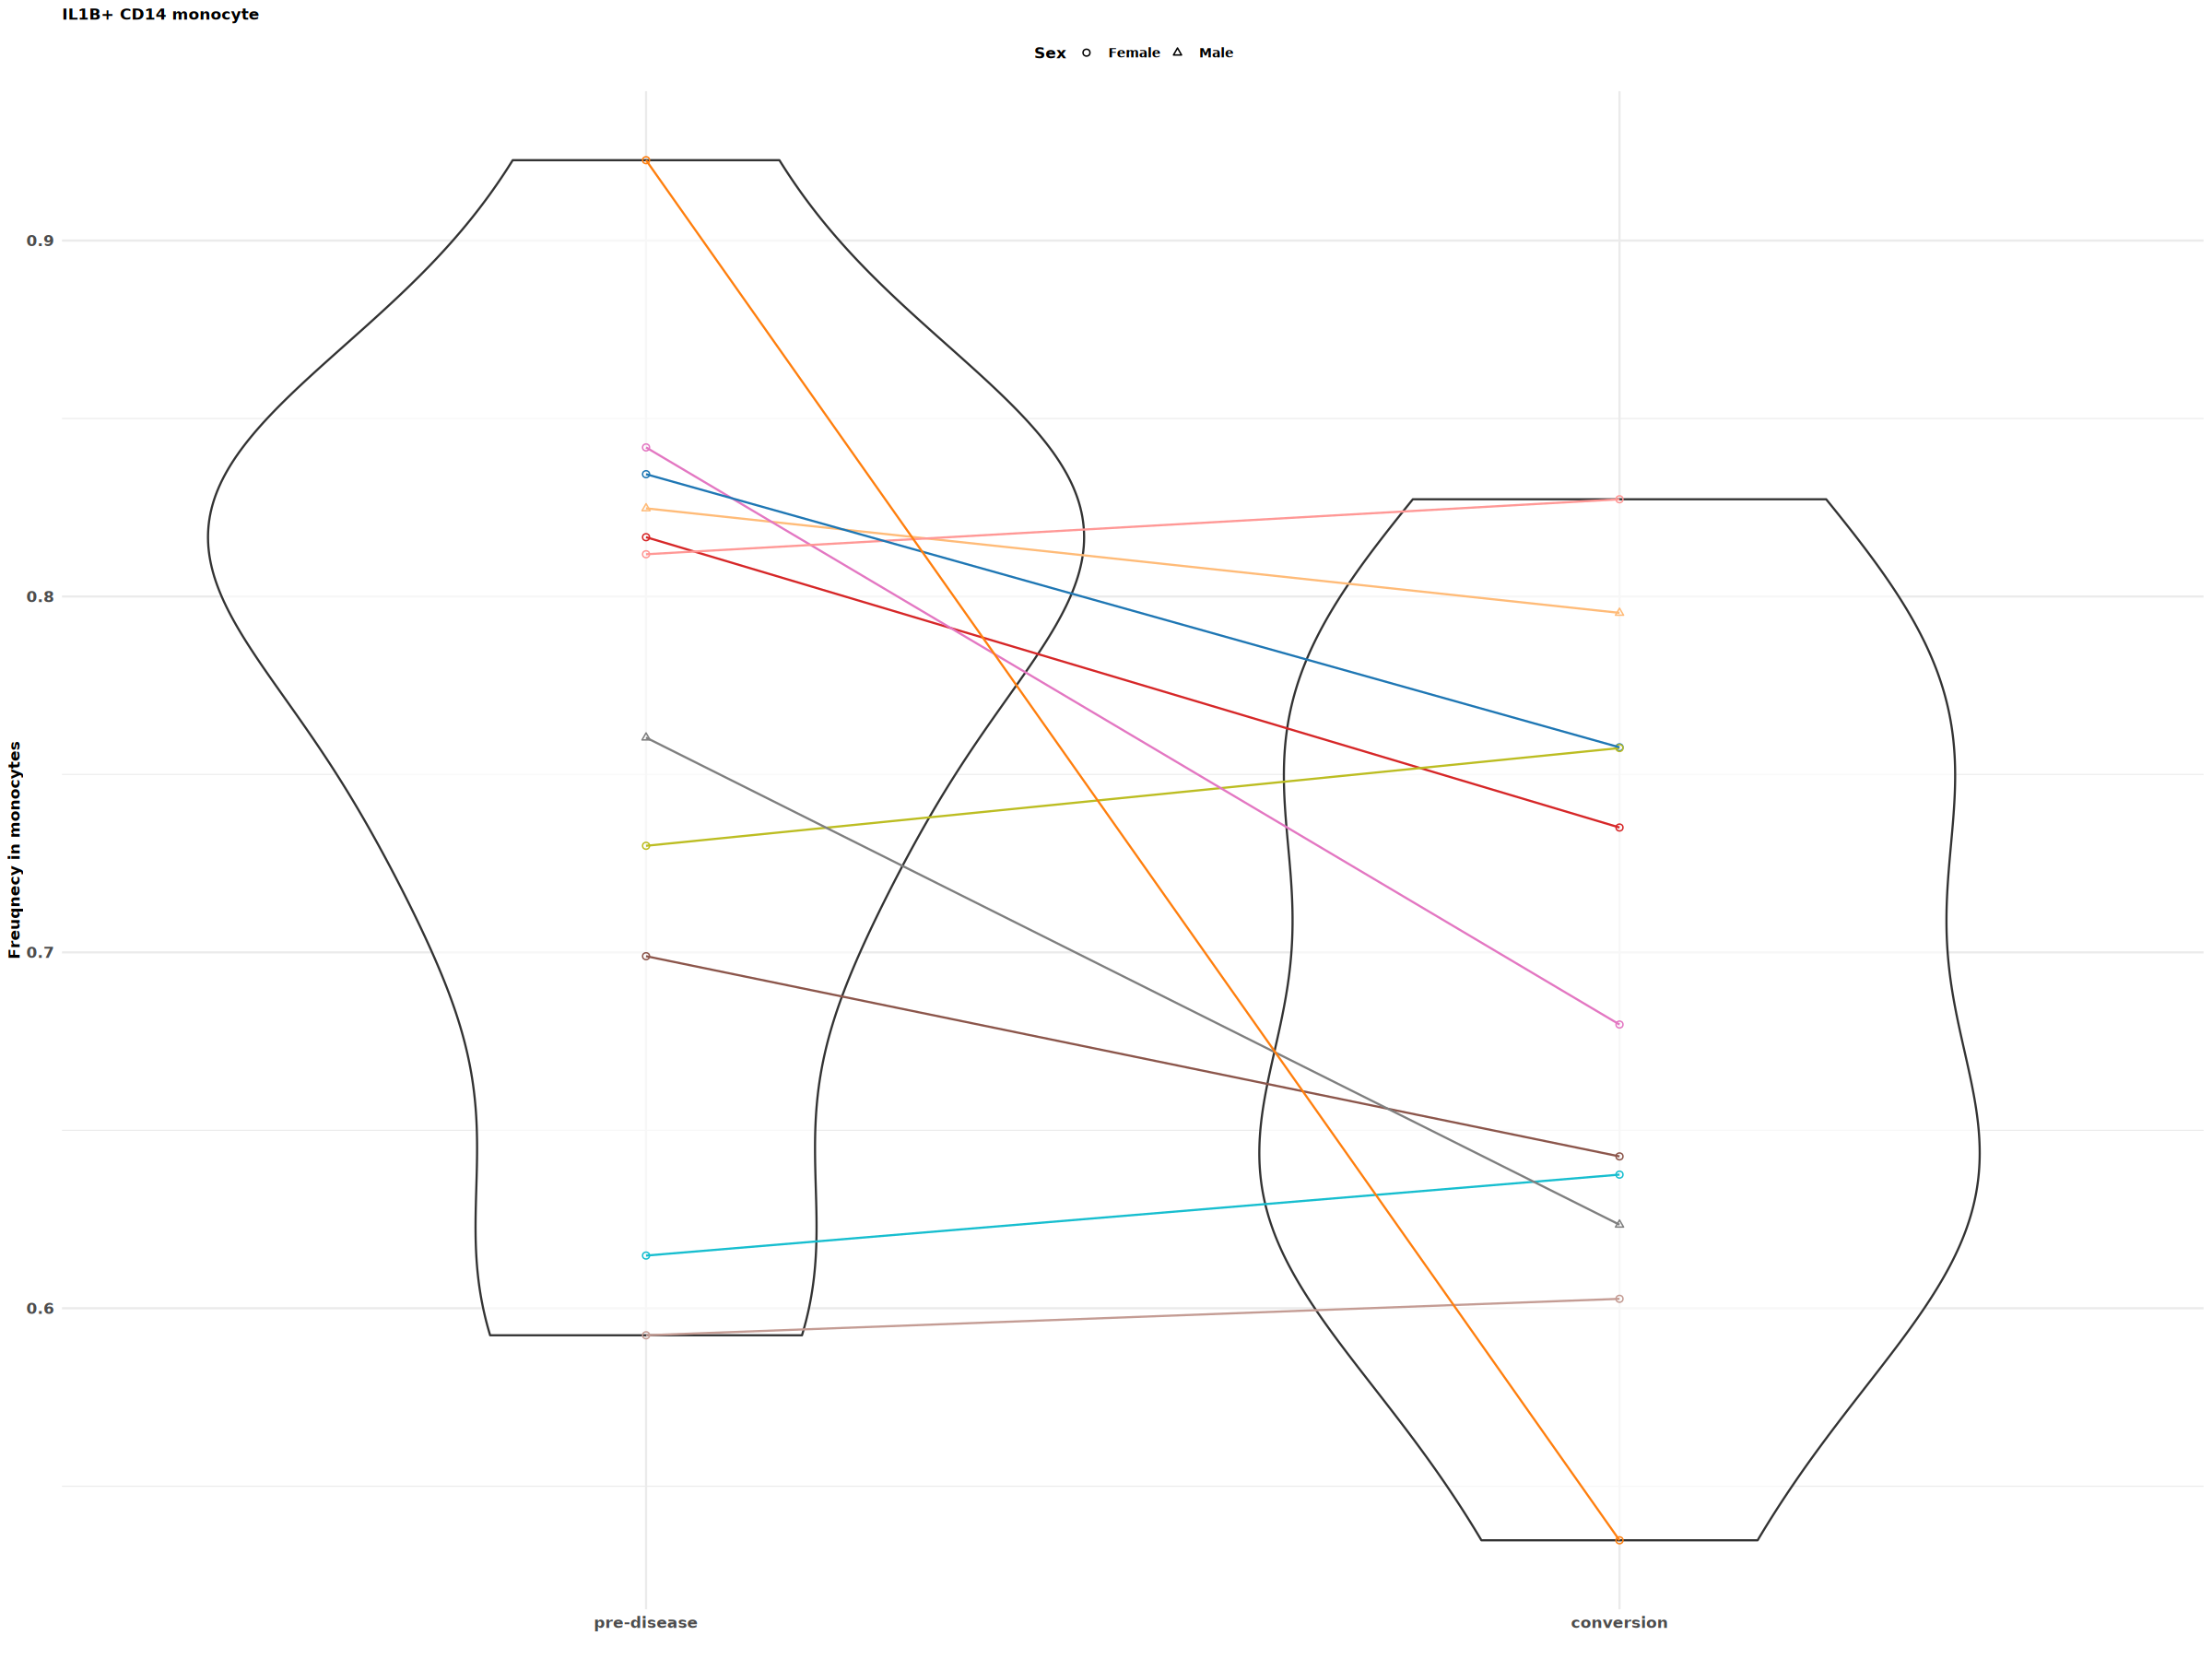

In [22]:
p2 <- mono_freq_clr %>% filter(cell_type=='Core CD14 monocyte') %>% 
        ggplot(aes(x = status, y = mono_frequency)) +
        geom_violin(aes(), alpha = 0.6) +
        geom_point(aes(group = subject.subjectGuid, color = subject.subjectGuid, shape = Sex)) +
        geom_line(aes(group = subject.subjectGuid, color = subject.subjectGuid)) +
        labs(title = "IL1B+ CD14 monocyte", x = "", y = "Freuqnecy in monocytes") +
        scale_color_subj() +
        theme_minimal() +
        theme(
            text = element_text(size = 10, face = "bold"),
            axis.title = element_text(size = 10, face = "bold"),
            axis.text = element_text(size = 10, face = "bold"),
            plot.title = element_text(size = 10, face = "bold"),
            legend.position = "top"
        ) +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = 'none', fill = 'none')
p2
ggsave(file.path(fig_path, paste0(proj_name, "paired_monocyte_cd14mon_freq.pdf")), width = 4, height = 4)

### calcualte the il1b cd14 mono within the cd14 mono

In [6]:
mono_freq%>%distinct(cell_type)

cell_type
<fct>
C1Q+ CD16 monocyte
Core CD14 monocyte
Core CD16 monocyte
IL1B+ CD14 monocyte
ISG+ CD14 monocyte
ISG+ CD16 monocyte
Intermediate monocyte


In [7]:
# calcualte the il1b cd14 monocyte within the cd14 mono
cd14mon_freq <- mono_freq%>%filter(str_detect(cell_type, 'CD14 monocyte'))%>% select(-`...1`)%>%
    group_by(sample.sampleKitGuid)%>% mutate(total_cd14mono_counts = sum(counts))%>%
    mutate(cell_type = if_else(cell_type=='IL1B+ CD14 monocyte', 'IL1B+ CD14 monocyte', 'Other CD14 monocyte'))%>%
    ungroup()%>%
    group_by(sample.sampleKitGuid, cell_type)%>%mutate(counts=sum(counts), mono_frequency=sum(mono_frequency))%>% distinct()%>%
    mutate(cd14mono_frequency = counts/total_cd14mono_counts)%>%ungroup()
cd14mon_freq%>%head()

sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex,total_cd14mono_counts,cd14mono_frequency
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
KT00103,Other CD14 monocyte,715,SD1003,Female,Pre-clinical RA,B046,815,0.877300613,Female,718,0.995821727
KT00103,IL1B+ CD14 monocyte,3,SD1003,Female,Pre-clinical RA,B046,815,0.003680982,Female,718,0.004178273
KT00105,Other CD14 monocyte,4517,SD1007,Female,Pre-clinical RA,B070,4689,0.963318405,Female,4525,0.998232044
KT00105,IL1B+ CD14 monocyte,8,SD1007,Female,Pre-clinical RA,B070,4689,0.001706121,Female,4525,0.001767956
KT00109,Other CD14 monocyte,1488,SD1003,Female,Clinical RA,B046,1741,0.854681218,Female,1498,0.993324433
KT00109,IL1B+ CD14 monocyte,10,SD1003,Female,Clinical RA,B046,1741,0.005743825,Female,1498,0.006675567


In [8]:
cd14mon_freq%>%distinct(cell_type)

cell_type
<chr>
Other CD14 monocyte
IL1B+ CD14 monocyte


In [9]:
cd14mon_freq%>%filter(cell_type=='IL1B+ CD14 monocyte'&cd14mono_frequency>0.05)

sample.sampleKitGuid,cell_type,counts,subject.subjectGuid,subject.biologicalSex,status,file.batchID,total_mono_counts,mono_frequency,Sex,total_cd14mono_counts,cd14mono_frequency
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
KT02135,IL1B+ CD14 monocyte,111,CU1003,Female,Clinical RA,B087,1642,0.06760049,Female,1413,0.07855626
KT02844,IL1B+ CD14 monocyte,98,CU1029,Female,Clinical RA,B103,1514,0.06472919,Female,1159,0.08455565
KT04108,IL1B+ CD14 monocyte,191,CU1010,Female,Clinical RA,B164,2450,0.07795918,Female,2009,0.09507218
KT04474,IL1B+ CD14 monocyte,73,CU1010,Female,Pre-clinical RA,B178,1729,0.04222094,Female,1348,0.05415430


In [13]:
cd14mon_freq%>%distinct(sample.sampleKitGuid)

sample.sampleKitGuid
<chr>
KT00103
KT00105
KT00109
KT00468
KT00493
KT00500
KT00790
KT02135
KT02164


In [12]:
cd14mon_freq%>%write_csv(file.path(output_path, 'Paired_IL1bmono_frequency_table.csv'))

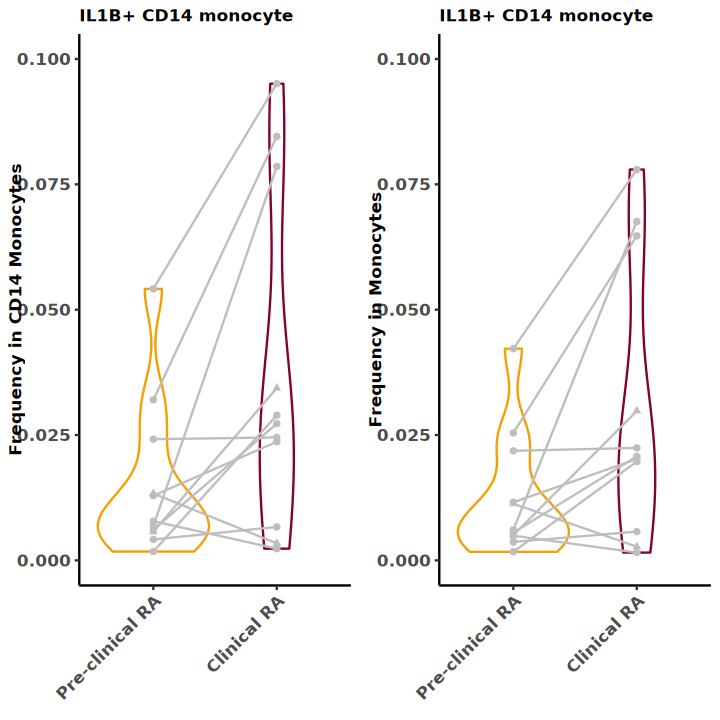

In [89]:
p1<-pairViolinPlot(cd14mon_freq, celltype_plot = 'IL1B+ CD14 monocyte', y_axis = 'cd14mono_frequency', 
               ylab = 'Frequency in CD14 Monocytes',
               group_colors = ari_colors) + ylim(0, 0.1)
p2<-pairViolinPlot(cd14mon_freq, celltype_plot = 'IL1B+ CD14 monocyte', y_axis = 'mono_frequency', 
               ylab = 'Frequency in Monocytes',
               group_colors = ari_colors)+ ylim(0, 0.1)
cowplot::plot_grid(p1, p2)

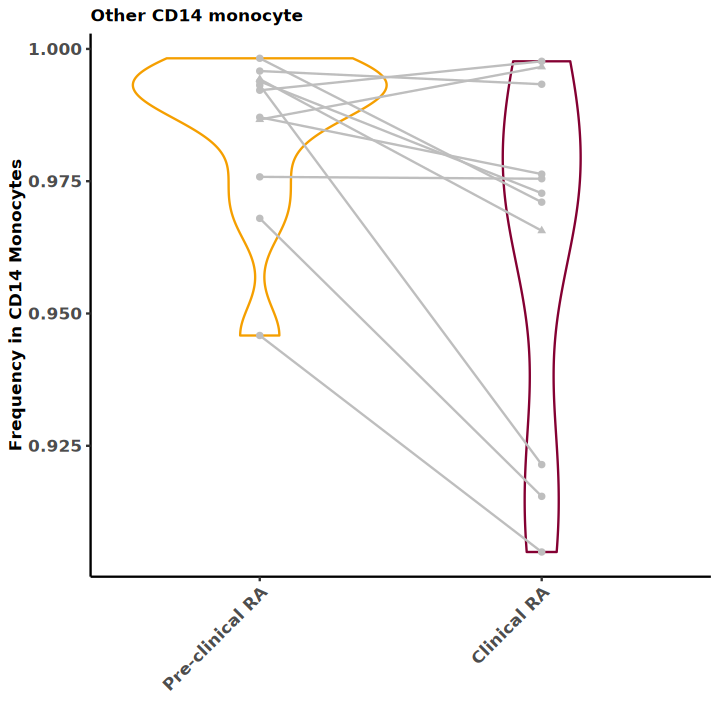

In [72]:
pairViolinPlot(cd14mon_freq, celltype_plot = 'Other CD14 monocyte', y_axis = 'cd14mono_frequency', 
               ylab = 'Frequency in CD14 Monocytes',
               group_colors = ari_colors)

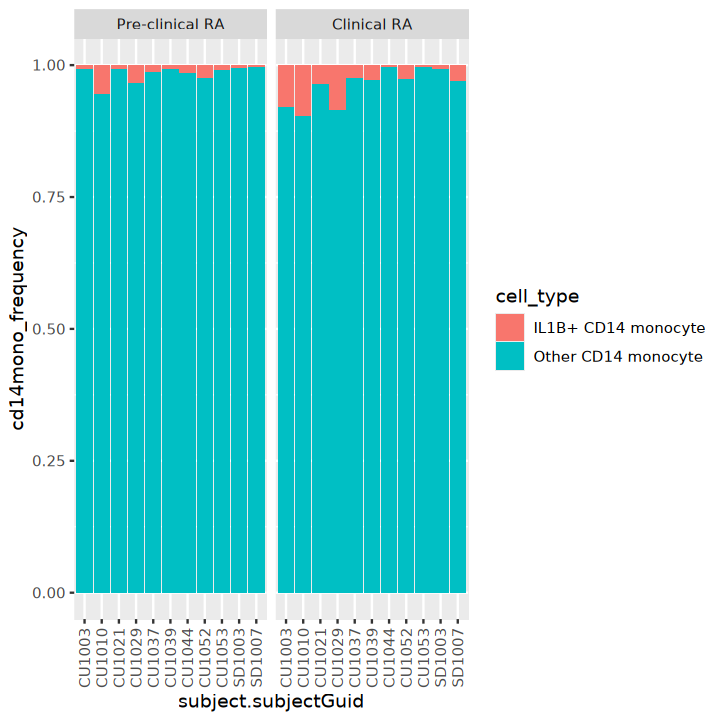

In [76]:
cd14mon_freq%>%ggplot(aes(x=subject.subjectGuid, y=cd14mono_frequency, fill=cell_type))+ 
    geom_bar(position="fill", stat="identity") + facet_wrap(vars(status)) +
    theme(axis.text.x = element_text(angle=90, vjust=.5, hjust=1))
ggsave(file.path(fig_path, 'Paired_conversion_IL1b_mono_cd14mono_frequency.pdf'), width = 6, height = 3)

In [65]:
 # run wilcox test for frequency pretreatment vs healthy 
freq_stats_wilcox_pair <- cd14mon_freq %>% #filter(cell_type%in%c('IL1B+ CD14 monocyte'))%>%
    group_by(cell_type) %>% arrange(subject.subjectGuid)%>%
    rstatix::wilcox_test(data =., cd14mono_frequency ~ status, paired = TRUE) %>%
      rstatix::adjust_pvalue(method = "BH") %>% 
      rstatix::add_significance("p.adj") 
    #calQvalue(p_col = 'p')
freq_stats_wilcox_pair

cell_type,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
IL1B+ CD14 monocyte,cd14mono_frequency,Pre-clinical RA,Clinical RA,11,11,7,0.0186,0.0186,*
Other CD14 monocyte,cd14mono_frequency,Pre-clinical RA,Clinical RA,11,11,59,0.0186,0.0186,*


### calcualte C8 macrophage scores (related to Fig 2H)

In [94]:
c8_scores = read_csv('/home/jupyter/data/ra_longitudinal/output_results/cd16mono/ALTRA_mono_C8_scores.csv', 
                    show_col_types = FALSE)

New names:
• `` -> `...1`


In [99]:
c8_avg_scores = c8_scores%>%group_by(AIFI_L3_new, sample.sampleKitGuid)%>%summarise(c8_score=mean(c8_score))%>%
    ungroup()

`summarise()` has grouped output by 'AIFI_L3_new'. You can override using the
`.groups` argument.


In [100]:
c8_avg_scores%>%rstatix::kruskal_test(c8_score ~ AIFI_L3_new)  

,.y.,n,statistic,df,p,method
,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>
1,c8_score,154,83.3971,6,7.09e-16,Kruskal-Wallis


In [101]:
c8_avg_scores%>%rstatix::dunn_test(c8_score ~ AIFI_L3_new) %>%filter()

,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,c8_score,C1Q+ CD16 monocyte,Core CD14 monocyte,22,22,0.2535125,7.998722e-01,1.000000e+00,ns
2,c8_score,C1Q+ CD16 monocyte,Core CD16 monocyte,22,22,0.5644878,5.724222e-01,1.000000e+00,ns
3,c8_score,C1Q+ CD16 monocyte,IL1B+ CD14 monocyte,22,22,6.1485226,7.820798e-10,1.564160e-08,****
4,c8_score,C1Q+ CD16 monocyte,Intermediate monocyte,22,22,-2.3931578,1.670406e-02,1.837446e-01,ns
5,c8_score,C1Q+ CD16 monocyte,ISG+ CD14 monocyte,22,22,1.8793725,6.019365e-02,4.815492e-01,ns
6,c8_score,C1Q+ CD16 monocyte,ISG+ CD16 monocyte,22,22,2.2545710,2.416027e-02,2.416027e-01,ns
7,c8_score,Core CD14 monocyte,Core CD16 monocyte,22,22,0.3109753,7.558194e-01,1.000000e+00,ns
8,c8_score,Core CD14 monocyte,IL1B+ CD14 monocyte,22,22,5.8950101,3.746584e-09,7.118509e-08,****
9,c8_score,Core CD14 monocyte,Intermediate monocyte,22,22,-2.6466703,8.128857e-03,9.754629e-02,ns


In [83]:
# p2 <- cd14mon_freq_clr %>% filter(cell_type%in%c('IL1B+ CD14 monocyte','Core CD14 monocyte')) %>% 
#         ggplot(aes(x = status, y = cd14mono_frequency)) +
#         geom_violin(aes(), alpha = 0.6) +
#         geom_point(aes(group = subject.subjectGuid, color = subject.subjectGuid, shape = Sex)) +
#         geom_line(aes(group = subject.subjectGuid, color = subject.subjectGuid)) +
#         labs(title = "", x = "", y = "Freuqnecy in CD14 monocytes") +
#         scale_color_subj() +
#         facet_wrap(vars(cell_type), scales = 'free_y') +
#         theme_minimal() +
#         theme(
#             text = element_text(size = 10, face = "bold"),
#             axis.title = element_text(size = 10, face = "bold"),
#             axis.text = element_text(size = 10, face = "bold"),
#             plot.title = element_text(size = 10, face = "bold"),
#             legend.position = "top"
#         ) +
#         scale_shape_manual(values = c(1, 2)) +
#         guides(color = 'none', fill = 'none') + ggthemes::theme_few()
# p2
# ggsave(file.path(fig_path, paste0(proj_name, "paired_monocyte_il1b_core_cd14mon_freq.pdf")), width = 6, height = 3)